In [1]:
# ============================================================
# CELL 1 — Imports and Reproducibility
# ============================================================

import os
import gc
import json
import time
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices("GPU")))
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Num GPUs available: 2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Cell 1 — Imports and Reproducibility

This cell imports the libraries required for data preparation, model development, evaluation, visualization, and experiment tracking.

A fixed random seed of 42 is used so that dataset splitting, shuffling, and model initialization are as reproducible as possible across runs.

The cell also checks the TensorFlow version and available GPU devices. GPU acceleration is important because DenseNet121 is a relatively large convolutional neural network.

In [2]:
# ============================================================
# CELL 2 — Configuration and Persistent Storage
# ============================================================

# Dataset
DATASET_DIR = Path(
    "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"
)

# Image configuration
IMG_HEIGHT = 160
IMG_WIDTH = 160
CHANNELS = 3
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Training configuration
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 2

# Dataset split
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Output directories
BASE_DIR = Path("/kaggle/working/malaria_densenet121")

MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
RESULT_DIR = BASE_DIR / "results"
PLOT_DIR = BASE_DIR / "plots"

for directory in [BASE_DIR, MODEL_DIR, LOG_DIR, RESULT_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = RESULT_DIR / "experiment_results.csv"
RESULTS_JSON = RESULT_DIR / "experiment_results.json"

AUTOTUNE = tf.data.AUTOTUNE

print("Dataset:", DATASET_DIR)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)
print("Output directory:", BASE_DIR)

Dataset: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images
Image size: (160, 160)
Batch size: 32
Maximum epochs: 10
Output directory: /kaggle/working/malaria_densenet121


## Cell 2 — Configuration and Persistent Storage

This cell defines the main experimental settings.

Images are resized to 160×160 RGB images and batches of 32 are used. The dataset is divided into 70% training, 15% validation, and 15% held-out test data.

The `/kaggle/working/malaria_densenet121` directory is created to store models, TensorBoard logs, experiment results, and plots.

Importantly, the experiment results will be written to disk after every experiment rather than existing only in a Python variable. This protects the experiment record from being lost if the notebook kernel is restarted.

In [4]:
# ============================================================
# CELL 3 — Verify Dataset Structure
# ============================================================

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory does not exist:\n{DATASET_DIR}"
    )

print("Dataset directory exists:", DATASET_DIR)

print("\nContents:")
for item in sorted(DATASET_DIR.iterdir()):
    print(" -", item.name)

required_classes = ["Uninfected", "Parasitized"]

for class_name in required_classes:
    class_dir = DATASET_DIR / class_name

    if not class_dir.exists():
        raise FileNotFoundError(
            f"Required class directory not found: {class_dir}"
        )

    print(
        f"\n{class_name}:",
        len(list(class_dir.glob("*")))
    )

print("\nDataset structure verified successfully.")

Dataset directory exists: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images

Contents:
 - Parasitized
 - Uninfected
 - cell_images

Uninfected: 13780

Parasitized: 13780

Dataset structure verified successfully.


## Cell 3 — Verify Dataset Structure

This cell confirms that the expected malaria dataset is available and that the two required class directories exist:

- Uninfected
- Parasitized

The additional nested `cell_images` directory, if present, is deliberately ignored. Only the two actual class folders are used for the classification task.

In [6]:
# ============================================================
# CELL 4 — Collect Image Paths and Labels
# ============================================================

CLASS_NAMES = {
    "Uninfected": 0,
    "Parasitized": 1
}

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp"
}

filepaths = []
labels = []
class_names = []

for class_name, label in CLASS_NAMES.items():

    class_dir = DATASET_DIR / class_name

    for file_path in class_dir.iterdir():

        if (
            file_path.is_file()
            and file_path.suffix.lower() in VALID_EXTENSIONS
        ):
            filepaths.append(str(file_path))
            labels.append(label)
            class_names.append(class_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels,
    "class_name": class_names
})

df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Total images:", len(df))

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nLabel mapping:")
print(CLASS_NAMES)

display(df.head())

Total images: 27558

Class distribution:
class_name
Uninfected     13779
Parasitized    13779
Name: count, dtype: int64

Label mapping:
{'Uninfected': 0, 'Parasitized': 1}


,filepath,label,class_name
0,/kaggle/input/datasets/iarunava/cell-images-fo...,0,Uninfected
1,/kaggle/input/datasets/iarunava/cell-images-fo...,0,Uninfected
2,/kaggle/input/datasets/iarunava/cell-images-fo...,1,Parasitized
3,/kaggle/input/datasets/iarunava/cell-images-fo...,1,Parasitized
4,/kaggle/input/datasets/iarunava/cell-images-fo...,1,Parasitized


## Cell 4 — Collect Image Paths and Labels

This cell creates a dataframe containing the path, numerical label, and class name for every image.

The class mapping is:

- `0 = Uninfected`
- `1 = Parasitized`

The images are shuffled using the fixed random seed before splitting.

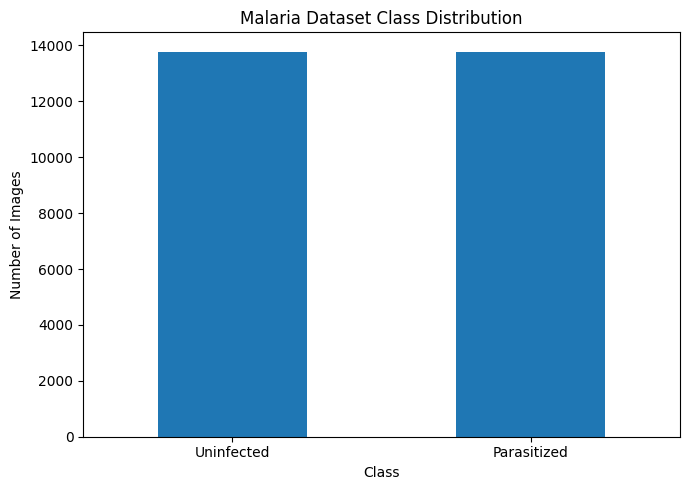

class_name
Uninfected     13779
Parasitized    13779
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 5 — Class Distribution Visualization
# ============================================================

class_counts = df["class_name"].value_counts()

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")
plt.title("Malaria Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(class_counts)

## Cell 5 — Class Distribution Visualization

This cell visualizes the number of images in each class.

The dataset is expected to be approximately balanced between infected (Parasitized) and uninfected cells. A balanced dataset reduces the need for aggressive class weighting and makes accuracy, sensitivity, and specificity easier to interpret.

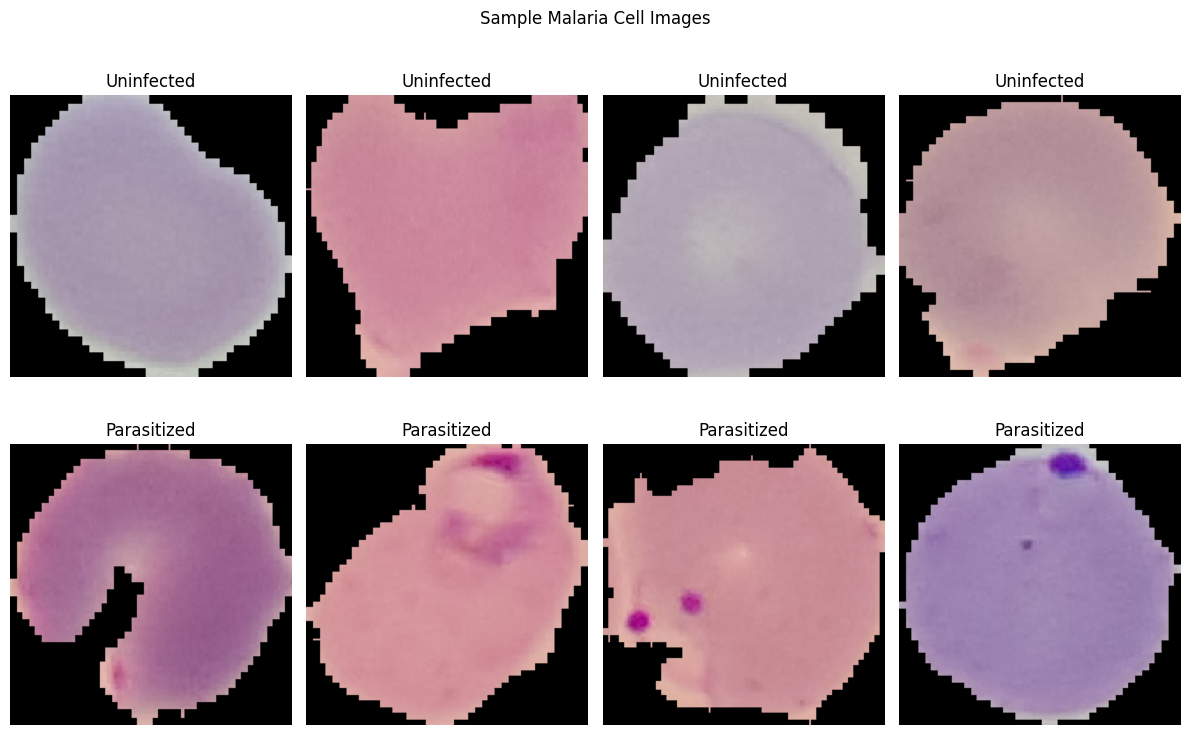

In [8]:
# ============================================================
# CELL 6 — Display Sample Images
# ============================================================

plt.figure(figsize=(12, 8))

sample_df = pd.concat([
    df[df["label"] == 0].sample(4, random_state=SEED),
    df[df["label"] == 1].sample(4, random_state=SEED)
]).reset_index(drop=True)

for i, row in sample_df.iterrows():

    image = tf.keras.utils.load_img(
        row["filepath"],
        target_size=IMAGE_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image).astype("uint8")

    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(image_array)
    ax.set_title(row["class_name"])
    ax.axis("off")

plt.suptitle("Sample Malaria Cell Images")
plt.tight_layout()
plt.show()

## Cell 6 — Sample Images

This cell displays representative examples from both classes.

Visual inspection is useful for confirming that the images have been loaded correctly and that the two classes represent malaria-infected and uninfected cells.

In [9]:
# ============================================================
# CELL 7 — Stratified 70/15/15 Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=df["label"],
    random_state=SEED
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nPercentages:")
print("Train:", len(train_df) / len(df))
print("Validation:", len(val_df) / len(df))
print("Test:", len(test_df) / len(df))

print("\nTrain class distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation class distribution:")
print(val_df["class_name"].value_counts())

print("\nTest class distribution:")
print(test_df["class_name"].value_counts())

Dataset sizes:
Train: 19290
Validation: 4134
Test: 4134

Percentages:
Train: 0.699978227737862
Validation: 0.15001088613106903
Test: 0.15001088613106903

Train class distribution:
class_name
Parasitized    9645
Uninfected     9645
Name: count, dtype: int64

Validation class distribution:
class_name
Uninfected     2067
Parasitized    2067
Name: count, dtype: int64

Test class distribution:
class_name
Uninfected     2067
Parasitized    2067
Name: count, dtype: int64


## Cell 7 — Stratified Train/Validation/Test Split

The dataset is divided into three independent subsets:

- 70% training
- 15% validation
- 15% held-out test

Stratification preserves the class proportions in each subset.

The test set is not used during model selection or hyperparameter tuning. It is reserved for the final evaluation so that the reported test performance represents an unseen evaluation.


In [10]:
# ============================================================
# CELL 8 — Image Loading Function
# ============================================================

def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=CHANNELS,
        expand_animations=False
    )

    image.set_shape([None, None, CHANNELS])

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.float32)

    return image, label


# Quick test
test_image, test_label = load_image(
    train_df.loc[0, "filepath"],
    train_df.loc[0, "label"]
)

print("Image shape:", test_image.shape)
print("Image dtype:", test_image.dtype)
print("Label:", test_label.numpy())

Image shape: (160, 160, 3)
Image dtype: <dtype: 'float32'>
Label: 1.0


I0000 00:00:1791373475.261317      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791373475.267033      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Cell 8 — Image Loading

This function reads each image directly from disk, decodes it as an RGB image, resizes it to 160×160 pixels, and converts the pixels to float32.

The function does not apply DenseNet preprocessing yet. That preprocessing is performed inside the model so that the experiment pipeline remains consistent.

In [11]:
# ============================================================
# CELL 9 — Create tf.data Pipelines
# ============================================================

def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets created successfully.")

for images, labels in train_ds.take(1):
    print("Batch images:", images.shape)
    print("Batch labels:", labels.shape)

Datasets created successfully.
Batch images: (32, 160, 160, 3)
Batch labels: (32,)


## Cell 9 — TensorFlow Data Pipelines

This cell converts the three dataframes into efficient `tf.data.Dataset` pipelines.

The training dataset is shuffled, while validation and test datasets are not shuffled. Batching and prefetching are used to improve GPU utilization and training efficiency.

In [12]:
# ============================================================
# CELL 10 — DenseNet Preprocessing and Augmentation
# ============================================================

class DenseNetPreprocess(tf.keras.layers.Layer):

    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(
            inputs
        )

    def get_config(self):
        return super().get_config()


def create_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip(
                mode="horizontal"
            ),
            tf.keras.layers.RandomRotation(
                factor=0.08
            ),
            tf.keras.layers.RandomZoom(
                height_factor=0.10,
                width_factor=0.10
            ),
            tf.keras.layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05
            )
        ],
        name="augmentation"
    )


print("DenseNet preprocessing layer and augmentation function created.")

DenseNet preprocessing layer and augmentation function created.


## Cell 10 — DenseNet Preprocessing and Augmentation

DenseNet121 expects its own application-specific preprocessing, so a dedicated preprocessing layer is defined.

The optional augmentation pipeline applies small horizontal flips, rotations, zooms, and translations. These transformations help the model learn features that are less dependent on the exact position or orientation of a cell.

The DenseNet documentation specifies that its `preprocess_input` should be applied to input images before they are passed to the pretrained network. :chatgpt-content-reference{index="2"}

In [14]:
# ============================================================
# CELL 11 — DenseNet121 Model Builder
# ============================================================

def build_densenet121(
    learning_rate=1e-3,
    dropout=0.0,
    l2_strength=0.0,
    use_augmentation=False,
    trainable_layers=0
):

    inputs = tf.keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        name="image"
    )

    x = inputs

    # Augmentation
    if use_augmentation:
        augmentation = create_augmentation()
        x = augmentation(x)

    # DenseNet preprocessing
    x = DenseNetPreprocess(
        name="densenet_preprocess"
    )(x)

    # Pretrained DenseNet121
    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
    )

    # Start with all layers frozen
    base_model.trainable = False

    # Optional fine-tuning
    if trainable_layers > 0:

        base_model.trainable = True

        # Freeze everything first
        for layer in base_model.layers:
            layer.trainable = False

        # Unfreeze only the final requested layers
        for layer in base_model.layers[-trainable_layers:]:

            # Keep BatchNorm frozen during fine-tuning
            if not isinstance(
                layer,
                tf.keras.layers.BatchNormalization
            ):
                layer.trainable = True

    # Keep pretrained BatchNorm in inference mode
    x = base_model(
        x,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(
            dropout,
            name="dropout_1"
        )(x)

    regularizer = (
        tf.keras.regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizer,
        name="dense_128"
    )(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(
            dropout,
            name="dropout_2"
        )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="malaria_probability"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="DenseNet121_Malaria"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model

## Cell 11 — DenseNet121 Model Builder

This cell defines the Transfer Learning Model 2 architecture.

DenseNet121 is initialized with ImageNet pretrained weights. Its original ImageNet classification head is removed, and a new binary classification head is added for malaria detection.

The first experiments freeze the pretrained DenseNet121 feature extractor. Later experiments progressively unfreeze the upper layers for fine-tuning.

Batch-normalization layers remain frozen during fine-tuning and the pretrained base is called with `training=False`, following the recommended Keras fine-tuning procedure. Fine-tuning should use a low learning rate because the pretrained representation can otherwise be damaged by large updates. :chatgpt-content-reference{index="3"}

In [15]:
# ============================================================
# CELL 12 — Model Sanity Check
# ============================================================

test_model = build_densenet121(
    learning_rate=1e-3,
    dropout=0.30,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=0
)

print("Model created successfully.")

print("\nParameter summary:")
test_model.summary()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in test_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in test_model.non_trainable_weights
])

print("\nTrainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)
print("Total parameters:", trainable_params + non_trainable_params)

del test_model
tf.keras.backend.clear_session()
gc.collect()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model created successfully.

Parameter summary:


Model: "DenseNet121_Malaria"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_preprocess             │ (None, 160, 160, 3)    │             0 │
│ (DenseNetPreprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malaria_probability (Dense)     │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)


Trainable parameters: 131329
Non-trainable parameters: 7037504
Total parameters: 7168833


0

## Cell 12 — Model Sanity Check

This cell creates one DenseNet121 model without training it and verifies that the architecture builds correctly.

The parameter counts are also displayed. At this stage, the pretrained convolutional base is frozen, so only the newly added classification head is trainable.

In [17]:
# ============================================================
# CELL 13 — Evaluation Function
# ============================================================

def get_predictions(model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:

        probabilities = model.predict(
            images,
            verbose=0
        ).ravel()

        y_prob.extend(probabilities)
        y_true.extend(labels.numpy())

    return (
        np.asarray(y_true).astype(int),
        np.asarray(y_prob)
    )


def calculate_metrics(
    y_true,
    y_prob,
    threshold=0.5
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


def evaluate_model(
    model,
    dataset,
    threshold=0.5
):

    y_true, y_prob = get_predictions(
        model,
        dataset
    )

    metrics = calculate_metrics(
        y_true,
        y_prob,
        threshold=threshold
    )

    return metrics

## Cell 13 — Evaluation Metrics

This cell defines the evaluation procedure used throughout the project.

The required metrics are calculated from predictions:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Sensitivity
- Specificity

For this binary problem, Parasitized is treated as the positive class (`1`). Therefore, sensitivity is the proportion of parasitized cells correctly identified, while specificity measures the proportion of uninfected cells correctly identified.

In [18]:
# ============================================================
# CELL 14 — Validation Threshold Tuning
# ============================================================

def find_best_threshold(
    y_true,
    y_prob,
    min_threshold=0.20,
    max_threshold=0.80,
    step=0.01
):

    thresholds = np.arange(
        min_threshold,
        max_threshold + step,
        step
    )

    records = []

    for threshold in thresholds:

        metrics = calculate_metrics(
            y_true,
            y_prob,
            threshold=float(threshold)
        )

        records.append(metrics)

    threshold_df = pd.DataFrame(records)

    # Primary goal:
    # maximize the weaker of sensitivity and specificity.
    threshold_df["min_sens_spec"] = threshold_df[
        ["sensitivity", "specificity"]
    ].min(axis=1)

    # Secondary criterion: F1
    threshold_df = threshold_df.sort_values(
        ["min_sens_spec", "f1"],
        ascending=False
    )

    best = threshold_df.iloc[0]

    return (
        float(best["threshold"]),
        threshold_df
    )


print("Threshold tuning function created.")

Threshold tuning function created.


## Cell 14 — Validation Threshold Tuning

The default binary classification threshold is 0.50, but the threshold can affect the balance between sensitivity and specificity.

For the final model, the threshold will be selected using the **validation set only**. The selection criterion maximizes the weaker of sensitivity and specificity, which directly reflects the assignment requirement.

The held-out test set will not be used to choose this threshold. This prevents test-set information from influencing model selection.

In [20]:
# ============================================================
# CELL 15 — Persistent Experiment Runner
# ============================================================

def save_json(data, path):

    with open(path, "w") as file:
        json.dump(
            data,
            file,
            indent=2
        )


def update_results_table(result):

    result_for_table = {
        key: value
        for key, value in result.items()
        if key != "history"
    }

    new_row = pd.DataFrame([
        result_for_table
    ])

    if RESULTS_CSV.exists():

        old_df = pd.read_csv(
            RESULTS_CSV
        )

        old_df = old_df[
            old_df["experiment"]
            != result["experiment"]
        ]

        combined_df = pd.concat(
            [old_df, new_row],
            ignore_index=True
        )

    else:

        combined_df = new_row

    combined_df.to_csv(
        RESULTS_CSV,
        index=False
    )

    save_json(
        combined_df.to_dict(
            orient="records"
        ),
        RESULTS_JSON
    )


def run_experiment(
    experiment_name,
    learning_rate=1e-3,
    dropout=0.0,
    l2_strength=0.0,
    use_augmentation=False,
    trainable_layers=0,
    epochs=10
):

    print("\n" + "=" * 80)
    print("STARTING:", experiment_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    start_time = time.time()

    model = build_densenet121(
        learning_rate=learning_rate,
        dropout=dropout,
        l2_strength=l2_strength,
        use_augmentation=use_augmentation,
        trainable_layers=trainable_layers
    )

    model_path = MODEL_DIR / f"{experiment_name}.keras"
    log_path = LOG_DIR / experiment_name
    history_path = RESULT_DIR / f"{experiment_name}_history.json"
    metrics_path = RESULT_DIR / f"{experiment_name}_metrics.json"

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.TensorBoard(
            log_dir=str(log_path),
            histogram_freq=0,
            write_graph=True,
            update_freq="epoch"
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    # Reload the actual best checkpoint.
    # This ensures evaluation uses the model selected by val_auc.
    del model
    tf.keras.backend.clear_session()
    gc.collect()

    best_model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "DenseNetPreprocess": DenseNetPreprocess
        },
        compile=False
    )

    # Compile for consistency if needed later
    best_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    validation_metrics = evaluate_model(
        best_model,
        val_ds,
        threshold=0.5
    )

    best_epoch = int(
        np.argmax(
            history.history["val_auc"]
        )
    ) + 1

    result = {
        "experiment": experiment_name,
        "learning_rate": learning_rate,
        "batch_size": BATCH_SIZE,
        "augmentation": use_augmentation,
        "dropout": dropout,
        "l2": l2_strength,
        "trainable_layers": trainable_layers,
        "best_epoch": best_epoch,
        "training_time_minutes": round(
            training_time / 60,
            3
        ),
        **validation_metrics,
        "history": history.history
    }

    # Save history
    save_json(
        history.history,
        history_path
    )

    # Save metrics
    save_json(
        validation_metrics,
        metrics_path
    )

    # Update master results table
    update_results_table(
        result
    )

    print("\n" + "=" * 80)
    print("COMPLETED:", experiment_name)
    print("=" * 80)

    print(
        f"Accuracy    : {validation_metrics['accuracy']:.4f}"
    )
    print(
        f"Precision   : {validation_metrics['precision']:.4f}"
    )
    print(
        f"Recall      : {validation_metrics['recall']:.4f}"
    )
    print(
        f"F1          : {validation_metrics['f1']:.4f}"
    )
    print(
        f"ROC-AUC     : {validation_metrics['roc_auc']:.4f}"
    )
    print(
        f"Sensitivity : {validation_metrics['sensitivity']:.4f}"
    )
    print(
        f"Specificity : {validation_metrics['specificity']:.4f}"
    )

    print("\nSaved model:")
    print(model_path)

    print("\nSaved TensorBoard logs:")
    print(log_path)

    print("\nSaved history:")
    print(history_path)

    print("\nSaved metrics:")
    print(metrics_path)

    # Clean memory
    del best_model
    tf.keras.backend.clear_session()
    gc.collect()

    return result

## Cell 15 — Persistent Experiment Runner

This is the main experiment engine.

For every experiment it:

1. Builds a fresh DenseNet121.
2. Applies the specified augmentation, dropout, regularization, learning rate, and fine-tuning configuration.
3. Trains for up to 10 epochs.
4. Uses EarlyStopping to stop when validation AUC stops improving.
5. Uses ReduceLROnPlateau to lower the learning rate when validation AUC plateaus.
6. Saves the best model using ModelCheckpoint.
7. Writes TensorBoard logs.
8. Evaluates the best checkpoint on the validation set.
9. Saves the complete training history.
10. Saves the experiment metrics.
11. Updates one master CSV/JSON results file.

This means the experiment record exists on disk even if the Python variable containing the result later disappears.

In [21]:
# ============================================================
# EXPERIMENT 1 — Frozen DenseNet121 Baseline
# ============================================================

result_01 = run_experiment(
    experiment_name="densenet121_exp_01_frozen_baseline",
    learning_rate=1e-3,
    dropout=0.0,
    l2_strength=0.0,
    use_augmentation=False,
    trainable_layers=0,
    epochs=EPOCHS
)


STARTING: densenet121_exp_01_frozen_baseline
Epoch 1/10


I0000 00:00:1791373878.206043     168 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8597 - auc: 0.9270 - loss: 0.3256 - precision: 0.8663 - recall: 0.8438
Epoch 1: val_auc improved from None to 0.97781, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_01_frozen_baseline.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_01_frozen_baseline.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 258s 382ms/step - accuracy: 0.8996 - auc: 0.9626 - loss: 0.2472 - precision: 0.9078 - recall: 0.8895 - val_accuracy: 0.9311 - val_auc: 0.9778 - val_loss: 0.1886 - val_precision: 0.9442 - val_recall: 0.9163 - learning_rate: 0.0010
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9260 - auc: 0.9769 - loss: 0.1927 - precision: 0.9347 - recall: 0.9160
Epoch 2: val_auc improved from 0.97781 to 0.98120, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_01_frozen_baseline.keras

Epoch 2: finished saving model to /kaggle/working/malari

## Experiment 1 — Frozen DenseNet121 Baseline

This experiment establishes a baseline using ImageNet-pretrained DenseNet121 with the convolutional base completely frozen.

Only the new malaria classification head is trained. No data augmentation, dropout, or L2 regularization is used.

This gives us a reference point for measuring whether each subsequent modification improves the model.

In [23]:
# ============================================================
# CELL 17 — EXPERIMENT 2
# Frozen DenseNet121 + Augmentation
# Maximum: 5 epochs
# ============================================================

result_02 = run_experiment(
    experiment_name="densenet121_exp_02_augmentation",
    learning_rate=1e-3,
    dropout=0.0,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=0,
    epochs=5
)

print("\n" + "=" * 80)
print("EXPERIMENT 2 FINISHED")
print("=" * 80)

print(f"Accuracy:    {result_02['accuracy']:.4f}")
print(f"Precision:   {result_02['precision']:.4f}")
print(f"Recall:      {result_02['recall']:.4f}")
print(f"F1:          {result_02['f1']:.4f}")
print(f"ROC-AUC:     {result_02['roc_auc']:.4f}")
print(f"Sensitivity: {result_02['sensitivity']:.4f}")
print(f"Specificity: {result_02['specificity']:.4f}")


STARTING: densenet121_exp_02_augmentation
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8678 - auc: 0.9358 - loss: 0.3138 - precision: 0.8740 - recall: 0.8633
Epoch 1: val_auc improved from None to 0.97268, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_02_augmentation.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_02_augmentation.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 87s 117ms/step - accuracy: 0.8959 - auc: 0.9591 - loss: 0.2586 - precision: 0.9005 - recall: 0.8901 - val_accuracy: 0.9187 - val_auc: 0.9727 - val_loss: 0.2121 - val_precision: 0.9369 - val_recall: 0.8979 - learning_rate: 0.0010
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9246 - auc: 0.9761 - loss: 0.1957 - precision: 0.9310 - recall: 0.9166
Epoch 2: val_auc improved from 0.97268 to 0.97621, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_02_augmentation.keras

Epoch 2: finish

### Experiment 2 — Augmentation

This experiment keeps DenseNet121 completely frozen but introduces image augmentation during training.

Compared with Experiment 1, this tests whether random image transformations improve generalization and reduce overfitting.

The experiment is limited to a maximum of 5 epochs. The best model according to validation ROC-AUC is saved together with its training history, metrics, and TensorBoard logs.

In [27]:
# ============================================================
# EXPERIMENT 3
# DenseNet121 + Data Augmentation + Dropout
# ============================================================

result_03 = run_experiment(
    experiment_name="densenet121_exp_03_aug_dropout",
    learning_rate=1e-3,
    dropout=0.30,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=0,
    epochs=5
)

print("\nExperiment 3 final validation metrics:")
for key, value in result_03.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        print(f"{key}: {value:.4f}")


STARTING: densenet121_exp_03_aug_dropout
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7989 - auc: 0.8716 - loss: 0.4498 - precision: 0.7993 - recall: 0.7885
Epoch 1: val_auc improved from None to 0.96736, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_03_aug_dropout.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_03_aug_dropout.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 80s 112ms/step - accuracy: 0.8407 - auc: 0.9178 - loss: 0.3657 - precision: 0.8440 - recall: 0.8359 - val_accuracy: 0.8858 - val_auc: 0.9674 - val_loss: 0.2662 - val_precision: 0.9478 - val_recall: 0.8166 - learning_rate: 0.0010
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8722 - auc: 0.9428 - loss: 0.3053 - precision: 0.8790 - recall: 0.8656
Epoch 2: val_auc improved from 0.96736 to 0.97073, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_03_aug_dropout.keras

Epoch 2: finished s

### Experiment 3 — Augmentation + Dropout

This experiment extends Experiment 2 by adding a 30% dropout layer to the DenseNet121 classification head. The DenseNet121 base remains frozen. Data augmentation is enabled to improve generalization, while dropout helps reduce overfitting. The model is trained for 5 epochs using a learning rate of 0.001.

In [28]:
# ============================================================
# EXPERIMENT 4
# DenseNet121 + Augmentation + Dropout + Lower Learning Rate
# ============================================================

result_04 = run_experiment(
    experiment_name="densenet121_exp_04_lr_1e-4",
    learning_rate=1e-4,
    dropout=0.30,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=0,
    epochs=5
)

print("\nExperiment 4 final validation metrics:")
for key, value in result_04.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        print(f"{key}: {value:.4f}")


STARTING: densenet121_exp_04_lr_1e-4
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6820 - auc: 0.7408 - loss: 0.6533 - precision: 0.6846 - recall: 0.6893
Epoch 1: val_auc improved from None to 0.95854, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_04_lr_1e-4.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_04_lr_1e-4.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 79s 111ms/step - accuracy: 0.7575 - auc: 0.8382 - loss: 0.5099 - precision: 0.7579 - recall: 0.7568 - val_accuracy: 0.8824 - val_auc: 0.9585 - val_loss: 0.2879 - val_precision: 0.9150 - val_recall: 0.8433 - learning_rate: 1.0000e-04
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8371 - auc: 0.9145 - loss: 0.3726 - precision: 0.8386 - recall: 0.8300
Epoch 2: val_auc improved from 0.95854 to 0.96411, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_04_lr_1e-4.keras

Epoch 2: finished saving model 

### Experiment 4 — Lower Learning Rate

This experiment keeps the augmentation and 30% dropout from Experiment 3 but reduces the learning rate from 0.001 to 0.0001. The DenseNet121 feature extractor remains frozen. The goal is to determine whether more conservative updates to the classification head improve validation performance.

In [29]:
# ============================================================
# EXPERIMENT 5
# DenseNet121 Fine-Tuning - Last 20 Layers
# ============================================================

result_05 = run_experiment(
    experiment_name="densenet121_exp_05_unfreeze_last20",
    learning_rate=1e-5,
    dropout=0.30,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=20,
    epochs=5
)

print("\nExperiment 5 final validation metrics:")
for key, value in result_05.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        print(f"{key}: {value:.4f}")


STARTING: densenet121_exp_05_unfreeze_last20
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5865 - auc: 0.6262 - loss: 0.8071 - precision: 0.5833 - recall: 0.6152
Epoch 1: val_auc improved from None to 0.95254, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_05_unfreeze_last20.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_05_unfreeze_last20.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.6673 - auc: 0.7329 - loss: 0.6655 - precision: 0.6626 - recall: 0.6820 - val_accuracy: 0.8471 - val_auc: 0.9525 - val_loss: 0.3402 - val_precision: 0.9448 - val_recall: 0.7373 - learning_rate: 1.0000e-05
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8158 - auc: 0.8972 - loss: 0.4111 - precision: 0.8134 - recall: 0.8189
Epoch 2: val_auc improved from 0.95254 to 0.96518, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_05_unfreeze_last20.keras


### Experiment 5 — Fine-Tuning the Last 20 Layers

This experiment begins fine-tuning the pretrained DenseNet121 feature extractor by unfreezing its last 20 layers. The remaining layers stay frozen. A smaller learning rate of 0.00001 is used to make controlled updates to the pretrained features. Data augmentation and 30% dropout are retained.

In [30]:
# ============================================================
# EXPERIMENT 6
# DenseNet121 Fine-Tuning - Last 50 Layers
# ============================================================

result_06 = run_experiment(
    experiment_name="densenet121_exp_06_unfreeze_last50",
    learning_rate=1e-5,
    dropout=0.30,
    l2_strength=0.0,
    use_augmentation=True,
    trainable_layers=50,
    epochs=5
)

print("\nExperiment 6 final validation metrics:")
for key, value in result_06.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        print(f"{key}: {value:.4f}")


STARTING: densenet121_exp_06_unfreeze_last50
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6184 - auc: 0.6686 - loss: 0.7952 - precision: 0.6120 - recall: 0.6722
Epoch 1: val_auc improved from None to 0.95406, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_06_unfreeze_last50.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_06_unfreeze_last50.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 85s 118ms/step - accuracy: 0.7086 - auc: 0.7854 - loss: 0.6079 - precision: 0.6990 - recall: 0.7327 - val_accuracy: 0.8614 - val_auc: 0.9541 - val_loss: 0.3047 - val_precision: 0.9298 - val_recall: 0.7818 - learning_rate: 1.0000e-05
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8458 - auc: 0.9223 - loss: 0.3595 - precision: 0.8460 - recall: 0.8436
Epoch 2: val_auc improved from 0.95406 to 0.96945, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_06_unfreeze_last50.keras


### Experiment 6 — Fine-Tuning the Last 50 Layers

This experiment increases fine-tuning by unfreezing the last 50 layers of DenseNet121. A learning rate of 0.00001 is used to avoid large changes to the pretrained ImageNet features. Data augmentation and 30% dropout remain enabled.

In [31]:
# ============================================================
# EXPERIMENT 7
# DenseNet121 Fine-Tuning + L2 Regularization
# ============================================================

result_07 = run_experiment(
    experiment_name="densenet121_exp_07_finetune_l2",
    learning_rate=5e-6,
    dropout=0.20,
    l2_strength=1e-4,
    use_augmentation=True,
    trainable_layers=50,
    epochs=5
)

print("\nExperiment 7 final validation metrics:")
for key, value in result_07.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        print(f"{key}: {value:.4f}")


STARTING: densenet121_exp_07_finetune_l2
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6181 - auc: 0.6653 - loss: 0.7247 - precision: 0.6306 - recall: 0.5543
Epoch 1: val_auc improved from None to 0.95209, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_07_finetune_l2.keras

Epoch 1: finished saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_07_finetune_l2.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.7051 - auc: 0.7781 - loss: 0.5939 - precision: 0.7142 - recall: 0.6839 - val_accuracy: 0.8747 - val_auc: 0.9521 - val_loss: 0.3441 - val_precision: 0.9023 - val_recall: 0.8403 - learning_rate: 5.0000e-06
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8368 - auc: 0.9151 - loss: 0.3931 - precision: 0.8362 - recall: 0.8342
Epoch 2: val_auc improved from 0.95209 to 0.96500, saving model to /kaggle/working/malaria_densenet121/models/densenet121_exp_07_finetune_l2.keras

Epoch 2: finish

### Experiment 7 — Fine-Tuning with L2 Regularization

This final experiment fine-tunes the last 50 DenseNet121 layers while adding L2 regularization to the dense classification layer. The dropout rate is reduced to 20%, and the learning rate is reduced to 0.000005. These changes are intended to provide more stable fine-tuning while controlling overfitting.

In [32]:
# ============================================================
# CELL 23 — Experiment Results Table
# ============================================================

results_df = pd.read_csv(
    RESULTS_CSV
)

display(
    results_df[
        [
            "experiment",
            "learning_rate",
            "batch_size",
            "augmentation",
            "dropout",
            "l2",
            "trainable_layers",
            "best_epoch",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "sensitivity",
            "specificity"
        ]
    ].sort_values(
        "roc_auc",
        ascending=False
    ).reset_index(drop=True)
)

,experiment,learning_rate,batch_size,augmentation,dropout,l2,trainable_layers,best_epoch,accuracy,precision,recall,f1,roc_auc,sensitivity,specificity
0,densenet121_exp_01_frozen_baseline,0.001000,32,False,0.0,0.0000,0,9,0.944606,0.947856,0.940977,0.944404,0.985496,0.940977,0.948234
1,densenet121_exp_06_unfreeze_last50,0.000010,32,True,0.3,0.0000,50,5,0.932995,0.947500,0.916788,0.931891,0.981265,0.916788,0.949202
2,densenet121_exp_02_augmentation,0.001000,32,True,0.0,0.0000,0,5,0.907112,0.968802,0.841316,0.900570,0.979316,0.841316,0.972908
3,densenet121_exp_05_unfreeze_last20,0.000010,32,True,0.3,0.0000,20,5,0.921142,0.945725,0.893566,0.918905,0.978183,0.893566,0.948718
4,densenet121_exp_07_finetune_l2,0.000005,32,True,0.2,0.0001,50,5,0.922351,0.938253,0.904209,0.920916,0.976527,0.904209,0.940493
5,densenet121_exp_03_aug_dropout,0.001000,32,True,0.3,0.0000,0,5,0.917997,0.933735,0.899855,0.916482,0.974718,0.899855,0.936139
6,densenet121_exp_04_lr_1e-4,0.000100,32,True,0.3,0.0000,0,5,0.902032,0.933264,0.865989,0.898369,0.969665,0.865989,0.938075


## Cell 23 — Experiment Comparison

This cell reads the persistent results CSV and compares all seven experiments.

The experiments are ranked by validation ROC-AUC. Accuracy, precision, recall, F1, sensitivity, and specificity are also displayed.

The validation results are used to select the candidate final model. The held-out test set is still untouched at this stage.

In [33]:
# ============================================================
# CELL 24 — Select Best Candidate
# ============================================================

# We prioritize validation ROC-AUC while also requiring
# reasonably strong sensitivity and specificity.

eligible = results_df[
    (results_df["sensitivity"] >= 0.90) &
    (results_df["specificity"] >= 0.90)
].copy()

if len(eligible) > 0:

    candidate_row = eligible.sort_values(
        "roc_auc",
        ascending=False
    ).iloc[0]

    selection_reason = (
        "Highest validation ROC-AUC among experiments "
        "with both sensitivity and specificity >= 90%."
    )

else:

    candidate_row = results_df.sort_values(
        "roc_auc",
        ascending=False
    ).iloc[0]

    selection_reason = (
        "No experiment simultaneously reached 90% "
        "validation sensitivity and specificity, so the "
        "highest validation ROC-AUC experiment was selected "
        "for further threshold tuning."
    )

BEST_EXPERIMENT = candidate_row["experiment"]

BEST_MODEL_PATH = (
    MODEL_DIR / f"{BEST_EXPERIMENT}.keras"
)

print("Selected candidate:")
print(BEST_EXPERIMENT)

print("\nSelection reason:")
print(selection_reason)

print("\nModel path:")
print(BEST_MODEL_PATH)

print("\nCandidate validation metrics:")
display(
    pd.DataFrame([candidate_row])
)

Selected candidate:
densenet121_exp_01_frozen_baseline

Selection reason:
Highest validation ROC-AUC among experiments with both sensitivity and specificity >= 90%.

Model path:
/kaggle/working/malaria_densenet121/models/densenet121_exp_01_frozen_baseline.keras

Candidate validation metrics:


,experiment,learning_rate,batch_size,augmentation,dropout,l2,trainable_layers,best_epoch,training_time_minutes,accuracy,...,recall,f1,roc_auc,sensitivity,specificity,threshold,tn,fp,fn,tp
0,densenet121_exp_01_frozen_baseline,0.001,32,False,0.0,0.0,0,9,9.574,0.944606,...,0.940977,0.944404,0.985496,0.940977,0.948234,0.5,1960,107,122,1945


## Cell 24 — Select the Best Candidate

The strongest candidate is selected using the validation set.

If one or more experiments achieve at least 90% validation sensitivity and specificity, the experiment with the highest ROC-AUC among those models is selected.

If no experiment satisfies both conditions, the model with the highest validation ROC-AUC is selected and will undergo validation-only threshold tuning before final test evaluation.

This preserves the test set as an unseen evaluation set.

In [34]:
# ============================================================
# CELL 25 — Tune Final Classification Threshold on Validation Set
# ============================================================

final_candidate = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "DenseNetPreprocess": DenseNetPreprocess
    },
    compile=False
)

val_true, val_prob = get_predictions(
    final_candidate,
    val_ds
)

best_threshold, threshold_results = find_best_threshold(
    val_true,
    val_prob
)

val_metrics_05 = calculate_metrics(
    val_true,
    val_prob,
    threshold=0.50
)

val_metrics_tuned = calculate_metrics(
    val_true,
    val_prob,
    threshold=best_threshold
)

print("Default threshold = 0.50")
print(
    "Sensitivity:",
    f"{val_metrics_05['sensitivity']:.4f}"
)
print(
    "Specificity:",
    f"{val_metrics_05['specificity']:.4f}"
)

print("\nSelected validation threshold:")
print(best_threshold)

print("\nTuned validation performance:")
print(
    f"Accuracy    : {val_metrics_tuned['accuracy']:.4f}"
)
print(
    f"Precision   : {val_metrics_tuned['precision']:.4f}"
)
print(
    f"Recall      : {val_metrics_tuned['recall']:.4f}"
)
print(
    f"F1          : {val_metrics_tuned['f1']:.4f}"
)
print(
    f"ROC-AUC     : {val_metrics_tuned['roc_auc']:.4f}"
)
print(
    f"Sensitivity : {val_metrics_tuned['sensitivity']:.4f}"
)
print(
    f"Specificity : {val_metrics_tuned['specificity']:.4f}"
)

Default threshold = 0.50
Sensitivity: 0.9410
Specificity: 0.9482

Selected validation threshold:
0.47000000000000025

Tuned validation performance:
Accuracy    : 0.9453
Precision   : 0.9453
Recall      : 0.9453
F1          : 0.9453
ROC-AUC     : 0.9855
Sensitivity : 0.9453
Specificity : 0.9453


## Cell 25 — Validation Threshold Selection

The candidate model's probability threshold is tuned using only the validation set.

Instead of automatically assuming that 0.50 is optimal, several thresholds are tested. The selected threshold maximizes the weaker of sensitivity and specificity.

This is particularly appropriate for this assignment because both sensitivity and specificity are important. The test set remains completely untouched during this optimization.

In [36]:
# ============================================================
# CELL 26 — FINAL HELD-OUT TEST EVALUATION
# ============================================================

test_true, test_prob = get_predictions(
    final_candidate,
    test_ds
)

test_metrics = calculate_metrics(
    test_true,
    test_prob,
    threshold=best_threshold
)

print("=" * 70)
print("FINAL DENSENET121 HELD-OUT TEST RESULTS")
print("=" * 70)

print("Experiment:", BEST_EXPERIMENT)
print("Threshold:", f"{best_threshold:.2f}")

print(
    f"\nAccuracy    : {test_metrics['accuracy']:.4f}"
)
print(
    f"Precision   : {test_metrics['precision']:.4f}"
)
print(
    f"Recall      : {test_metrics['recall']:.4f}"
)
print(
    f"F1-score    : {test_metrics['f1']:.4f}"
)
print(
    f"ROC-AUC     : {test_metrics['roc_auc']:.4f}"
)
print(
    f"Sensitivity : {test_metrics['sensitivity']:.4f}"
)
print(
    f"Specificity : {test_metrics['specificity']:.4f}"
)

print("\nConfusion matrix counts:")
print(
    "TN:", test_metrics["tn"],
    "FP:", test_metrics["fp"],
    "FN:", test_metrics["fn"],
    "TP:", test_metrics["tp"]
)

if (
    test_metrics["sensitivity"] >= 0.90
    and test_metrics["specificity"] >= 0.90
):
    print(
        "\nPASS: Final DenseNet121 achieved "
        ">=90% sensitivity AND >=90% specificity."
    )
else:
    print(
        "\nThe final DenseNet121 did not reach both "
        "90% test sensitivity and specificity."
    )

FINAL DENSENET121 HELD-OUT TEST RESULTS
Experiment: densenet121_exp_01_frozen_baseline
Threshold: 0.47

Accuracy    : 0.9507
Precision   : 0.9498
Recall      : 0.9516
F1-score    : 0.9507
ROC-AUC     : 0.9874
Sensitivity : 0.9516
Specificity : 0.9497

Confusion matrix counts:
TN: 1963 FP: 104 FN: 100 TP: 1967

PASS: Final DenseNet121 achieved >=90% sensitivity AND >=90% specificity.


## Cell 26 — Final Held-Out Test Evaluation

This is the most important evaluation cell.

The selected DenseNet121 model is evaluated on the held-out test set using the threshold determined previously from the validation set.

The test set was not used to choose the model or threshold.

Sensitivity measures how well the model detects parasitized cells, while specificity measures how well it identifies uninfected cells.

The assignment target for the transfer-learning model is assessed here.

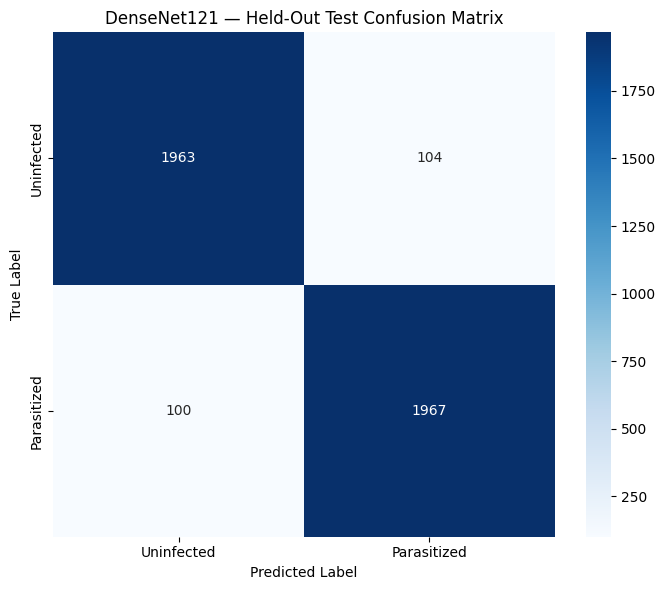

Saved: /kaggle/working/malaria_densenet121/plots/densenet121_confusion_matrix.png


In [37]:
# ============================================================
# CELL 27 — Final Confusion Matrix
# ============================================================

test_pred = (
    test_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Uninfected", "Parasitized"],
    yticklabels=["Uninfected", "Parasitized"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "DenseNet121 — Held-Out Test Confusion Matrix"
)

plt.tight_layout()

confusion_path = (
    PLOT_DIR / "densenet121_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", confusion_path)

## Cell 27 — Confusion Matrix

The confusion matrix shows the four possible classification outcomes:

- True negatives: correctly identified uninfected cells
- False positives: uninfected cells incorrectly classified as parasitized
- False negatives: parasitized cells incorrectly classified as uninfected
- True positives: correctly identified parasitized cells

These values provide the basis for calculating sensitivity and specificity.

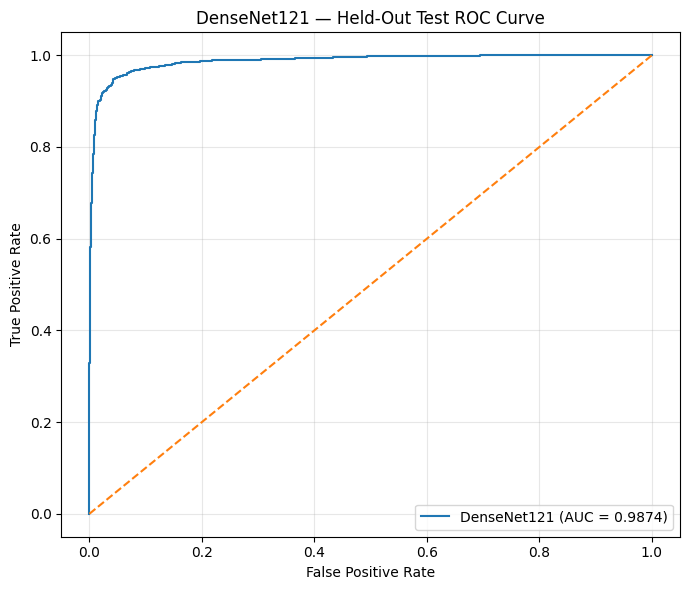

Saved: /kaggle/working/malaria_densenet121/plots/densenet121_test_roc_curve.png


In [38]:
# ============================================================
# CELL 28 — ROC Curve
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    test_true,
    test_prob
)

test_auc = roc_auc_score(
    test_true,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"DenseNet121 (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "DenseNet121 — Held-Out Test ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = (
    PLOT_DIR / "densenet121_test_roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", roc_path)

## Cell 28 — ROC Curve

The ROC curve shows the relationship between true-positive rate and false-positive rate across classification thresholds.

The area under the ROC curve (ROC-AUC) summarizes the model's ability to distinguish parasitized from uninfected cells across thresholds. A value closer to 1 indicates stronger discrimination.

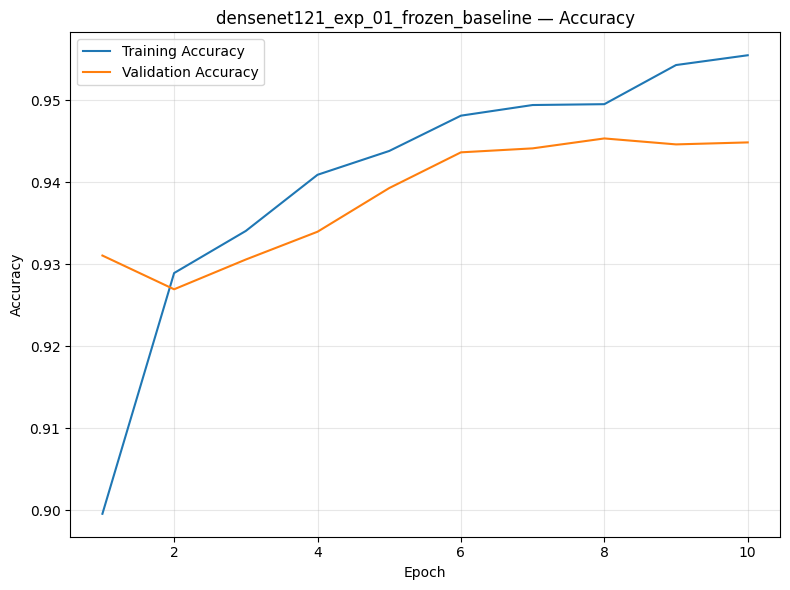

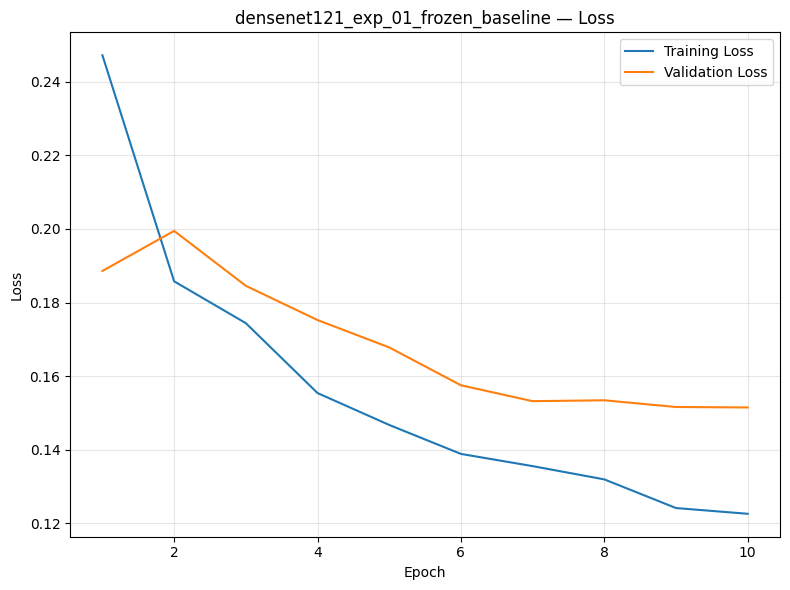

Saved accuracy curve: /kaggle/working/malaria_densenet121/plots/best_model_accuracy_curve.png
Saved loss curve: /kaggle/working/malaria_densenet121/plots/best_model_loss_curve.png


In [39]:
# ============================================================
# CELL 29 — Training Curves for Best Experiment
# ============================================================

history_path = (
    RESULT_DIR /
    f"{BEST_EXPERIMENT}_history.json"
)

with open(history_path, "r") as file:
    best_history = json.load(file)

epochs_range = range(
    1,
    len(best_history["loss"]) + 1
)

# Accuracy
plt.figure(figsize=(8, 6))

plt.plot(
    epochs_range,
    best_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    best_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    f"{BEST_EXPERIMENT} — Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_curve_path = (
    PLOT_DIR / "best_model_accuracy_curve.png"
)

plt.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Loss
plt.figure(figsize=(8, 6))

plt.plot(
    epochs_range,
    best_history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    best_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    f"{BEST_EXPERIMENT} — Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = (
    PLOT_DIR / "best_model_loss_curve.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved accuracy curve:", accuracy_curve_path)
print("Saved loss curve:", loss_curve_path)

## Cell 29 — Training and Validation Curves

These plots show how the selected DenseNet121 model learned over the training epochs.

The accuracy curve compares training and validation accuracy, while the loss curve compares training and validation loss.

Large divergence between training and validation performance can indicate overfitting. Similar curves with strong validation performance suggest better generalization.

DenseNet base model: densenet121
Number of Conv2D layers found: 120
Grad-CAM convolutional layer: conv5_block16_2_conv
Layer output shape: (None, 5, 5, 32)
Internal DenseNet Grad-CAM model created successfully.
Preprocessing layer: densenet_preprocess
Grad-CAM image:
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized/C132P93ThinF_IMG_20151004_152257_cell_117.png
Heatmap shape: (5, 5)
Predicted probability of Parasitized: 1.0000
Predicted class: Parasitized


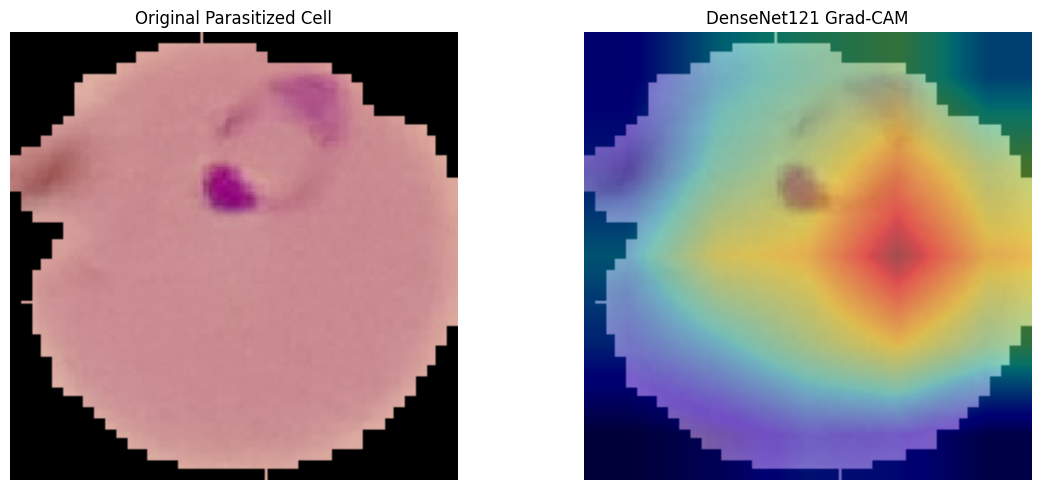

GRAD-CAM COMPLETED SUCCESSFULLY
DenseNet layer: conv5_block16_2_conv
Predicted probability: 1.0
Predicted class: Parasitized
Saved: /kaggle/working/malaria_densenet121/plots/densenet121_gradcam.png


In [43]:
# ============================================================
# CELL 30 — Grad-CAM Visualization (Keras 3 Safe Version)
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Get the DenseNet121 base model
# ------------------------------------------------------------

densenet_base = final_candidate.get_layer("densenet121")

print("DenseNet base model:", densenet_base.name)


# ------------------------------------------------------------
# 2. Find a proper final convolutional feature layer
# ------------------------------------------------------------

conv_layer_names = []

for layer in densenet_base.layers:

    if isinstance(layer, tf.keras.layers.Conv2D):

        try:
            if len(layer.output.shape) == 4:
                conv_layer_names.append(layer.name)
        except Exception:
            pass


print("Number of Conv2D layers found:", len(conv_layer_names))

if len(conv_layer_names) == 0:
    raise ValueError(
        "No Conv2D layer was found inside DenseNet121."
    )


last_conv_name = conv_layer_names[-1]

print("Grad-CAM convolutional layer:", last_conv_name)


# ------------------------------------------------------------
# 3. Get the selected convolutional layer
# ------------------------------------------------------------

last_conv_layer = densenet_base.get_layer(
    last_conv_name
)

print(
    "Layer output shape:",
    last_conv_layer.output.shape
)


# ------------------------------------------------------------
# 4. Build a Grad-CAM model INSIDE DenseNet121
# ------------------------------------------------------------

grad_model = tf.keras.models.Model(
    inputs=densenet_base.input,
    outputs=[
        last_conv_layer.output,
        densenet_base.output
    ]
)

print("Internal DenseNet Grad-CAM model created successfully.")


# ------------------------------------------------------------
# 5. Get DenseNet preprocessing layer
# ------------------------------------------------------------

preprocess_layer = final_candidate.get_layer(
    "densenet_preprocess"
)

print(
    "Preprocessing layer:",
    preprocess_layer.name
)


# ------------------------------------------------------------
# 6. Grad-CAM function
# ------------------------------------------------------------

def make_gradcam(
    original_image
):

    # Apply exactly the same preprocessing used by
    # the trained model
    preprocessed_image = preprocess_layer(
        original_image
    )

    with tf.GradientTape() as tape:

        tape.watch(preprocessed_image)

        conv_outputs, dense_output = grad_model(
            preprocessed_image,
            training=False
        )

        # Binary classifier output
        class_score = dense_output[:, 0]

    # Gradient of class score with respect to
    # convolutional feature maps
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    if grads is None:
        raise ValueError(
            "Gradients are None. Grad-CAM could not "
            "calculate gradients for the selected layer."
        )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps by gradient importance
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive activations
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize to 0–1
    max_value = tf.reduce_max(
        heatmap
    )

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()


# ------------------------------------------------------------
# 7. Select one parasitized test image
# ------------------------------------------------------------

gradcam_row = test_df[
    test_df["label"] == 1
].iloc[0]

image_path = gradcam_row["filepath"]

print("Grad-CAM image:")
print(image_path)


# ------------------------------------------------------------
# 8. Load image
# ------------------------------------------------------------

original_image = tf.keras.utils.load_img(
    image_path,
    target_size=IMAGE_SIZE
)

original_array = tf.keras.utils.img_to_array(
    original_image
).astype("uint8")


# ------------------------------------------------------------
# 9. Create model input
# ------------------------------------------------------------

input_tensor = tf.expand_dims(
    tf.cast(
        original_array,
        tf.float32
    ),
    axis=0
)


# ------------------------------------------------------------
# 10. Generate Grad-CAM heatmap
# ------------------------------------------------------------

heatmap = make_gradcam(
    input_tensor
)

print(
    "Heatmap shape:",
    heatmap.shape
)


# ------------------------------------------------------------
# 11. Resize heatmap to image dimensions
# ------------------------------------------------------------

heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    IMAGE_SIZE
).numpy().squeeze()


# ------------------------------------------------------------
# 12. Get prediction for the selected image
# ------------------------------------------------------------

prediction = final_candidate.predict(
    input_tensor,
    verbose=0
)[0][0]

predicted_class = (
    "Parasitized"
    if prediction >= 0.5
    else "Uninfected"
)

print(
    f"Predicted probability of Parasitized: "
    f"{prediction:.4f}"
)

print(
    "Predicted class:",
    predicted_class
)


# ------------------------------------------------------------
# 13. Display original image
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    original_array
)

plt.title(
    "Original Parasitized Cell"
)

plt.axis("off")


# ------------------------------------------------------------
# 14. Display Grad-CAM overlay
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.imshow(
    original_array
)

plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

plt.title(
    "DenseNet121 Grad-CAM"
)

plt.axis("off")

plt.tight_layout()


# ------------------------------------------------------------
# 15. Save Grad-CAM visualization
# ------------------------------------------------------------

gradcam_path = (
    PLOT_DIR /
    "densenet121_gradcam.png"
)

plt.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("GRAD-CAM COMPLETED SUCCESSFULLY")
print("=" * 70)
print("DenseNet layer:", last_conv_name)
print("Predicted probability:", round(float(prediction), 4))
print("Predicted class:", predicted_class)
print("Saved:", gradcam_path)

## Cell 30 — Grad-CAM

Grad-CAM is used to visualize which regions of a malaria cell contribute most strongly to the model's prediction.

The visualization overlays a heatmap on the original cell image. Regions with stronger activation indicate areas that contributed more to the classification decision.

This provides qualitative evidence that the model is focusing on biologically relevant visual structures rather than arbitrary image regions.

In [44]:
# ============================================================
# CELL 31 — Save Final Model and Final Results
# ============================================================

FINAL_MODEL_PATH = (
    MODEL_DIR / "densenet121_final.keras"
)

# Save the selected model
final_candidate.save(
    FINAL_MODEL_PATH
)

# Final result record
final_result = {
    "model": "DenseNet121",
    "selected_experiment": BEST_EXPERIMENT,
    "classification_threshold": best_threshold,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_roc_auc": test_metrics["roc_auc"],
    "test_sensitivity": test_metrics["sensitivity"],
    "test_specificity": test_metrics["specificity"],
    "tn": test_metrics["tn"],
    "fp": test_metrics["fp"],
    "fn": test_metrics["fn"],
    "tp": test_metrics["tp"]
}

FINAL_RESULTS_PATH = (
    RESULT_DIR / "final_densenet121_results.json"
)

save_json(
    final_result,
    FINAL_RESULTS_PATH
)

FINAL_RESULTS_CSV = (
    RESULT_DIR / "final_densenet121_results.csv"
)

pd.DataFrame([
    final_result
]).to_csv(
    FINAL_RESULTS_CSV,
    index=False
)

print("=" * 70)
print("FINAL FILES SAVED")
print("=" * 70)

print("Final model:")
print(FINAL_MODEL_PATH)

print("\nFinal JSON results:")
print(FINAL_RESULTS_PATH)

print("\nFinal CSV results:")
print(FINAL_RESULTS_CSV)

FINAL FILES SAVED
Final model:
/kaggle/working/malaria_densenet121/models/densenet121_final.keras

Final JSON results:
/kaggle/working/malaria_densenet121/results/final_densenet121_results.json

Final CSV results:
/kaggle/working/malaria_densenet121/results/final_densenet121_results.csv


## Cell 31 — Save Final Model and Results

This cell saves the selected DenseNet121 model separately as the final model.

It also creates final JSON and CSV files containing the held-out test performance, classification threshold, confusion-matrix counts, sensitivity, and specificity.

These files can be used when preparing the final report and documenting the model-selection process.

In [45]:
# ============================================================
# CELL 32 — Final File Verification
# ============================================================

print("=" * 80)
print("DENSENET121 PROJECT OUTPUTS")
print("=" * 80)

print("\nMODELS")
print("-" * 80)

for path in sorted(MODEL_DIR.glob("*")):
    print(path.name)

print("\nRESULTS")
print("-" * 80)

for path in sorted(RESULT_DIR.glob("*")):
    print(path.name)

print("\nTENSORBOARD LOGS")
print("-" * 80)

for path in sorted(LOG_DIR.iterdir()):
    print(path.name)

print("\nPLOTS")
print("-" * 80)

for path in sorted(PLOT_DIR.glob("*")):
    print(path.name)

print("\nMaster experiment results:")
display(
    pd.read_csv(RESULTS_CSV)
)

print("\nFinal test result:")
display(
    pd.DataFrame([final_result])
)

DENSENET121 PROJECT OUTPUTS

MODELS
--------------------------------------------------------------------------------
densenet121_exp_01_frozen_baseline.keras
densenet121_exp_02_augmentation.keras
densenet121_exp_03_aug_dropout.keras
densenet121_exp_04_lr_1e-4.keras
densenet121_exp_05_unfreeze_last20.keras
densenet121_exp_06_unfreeze_last50.keras
densenet121_exp_07_finetune_l2.keras
densenet121_final.keras

RESULTS
--------------------------------------------------------------------------------
densenet121_exp_01_frozen_baseline_history.json
densenet121_exp_01_frozen_baseline_metrics.json
densenet121_exp_02_augmentation_history.json
densenet121_exp_02_augmentation_metrics.json
densenet121_exp_03_aug_dropout_history.json
densenet121_exp_03_aug_dropout_metrics.json
densenet121_exp_04_lr_1e-4_history.json
densenet121_exp_04_lr_1e-4_metrics.json
densenet121_exp_05_unfreeze_last20_history.json
densenet121_exp_05_unfreeze_last20_metrics.json
densenet121_exp_06_unfreeze_last50_history.json
den

,experiment,learning_rate,batch_size,augmentation,dropout,l2,trainable_layers,best_epoch,training_time_minutes,accuracy,...,recall,f1,roc_auc,sensitivity,specificity,threshold,tn,fp,fn,tp
0,densenet121_exp_01_frozen_baseline,0.001000,32,False,0.0,0.0000,0,9,9.574,0.944606,...,0.940977,0.944404,0.985496,0.940977,0.948234,0.5,1960,107,122,1945
1,densenet121_exp_02_augmentation,0.001000,32,True,0.0,0.0000,0,5,5.602,0.907112,...,0.841316,0.900570,0.979316,0.841316,0.972908,0.5,2011,56,328,1739
2,densenet121_exp_03_aug_dropout,0.001000,32,True,0.3,0.0000,0,5,5.616,0.917997,...,0.899855,0.916482,0.974718,0.899855,0.936139,0.5,1935,132,207,1860
3,densenet121_exp_04_lr_1e-4,0.000100,32,True,0.3,0.0000,0,5,5.577,0.902032,...,0.865989,0.898369,0.969665,0.865989,0.938075,0.5,1939,128,277,1790
4,densenet121_exp_05_unfreeze_last20,0.000010,32,True,0.3,0.0000,20,5,5.704,0.921142,...,0.893566,0.918905,0.978183,0.893566,0.948718,0.5,1961,106,220,1847
5,densenet121_exp_06_unfreeze_last50,0.000010,32,True,0.3,0.0000,50,5,5.855,0.932995,...,0.916788,0.931891,0.981265,0.916788,0.949202,0.5,1962,105,172,1895
6,densenet121_exp_07_finetune_l2,0.000005,32,True,0.2,0.0001,50,5,5.829,0.922351,...,0.904209,0.920916,0.976527,0.904209,0.940493,0.5,1944,123,198,1869



Final test result:


,model,selected_experiment,classification_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_sensitivity,test_specificity,tn,fp,fn,tp
0,DenseNet121,densenet121_exp_01_frozen_baseline,0.47,0.950653,0.949783,0.951621,0.950701,0.987368,0.951621,0.949686,1963,104,100,1967


## Cell 32 — Final File Verification

This final verification cell lists all generated models, experiment results, TensorBoard logs, and visualizations.

The complete DenseNet121 experiment record should now include seven experiment models, seven TensorBoard log directories, experiment histories, the master experiment-results table, final evaluation results, and the required visualizations.

In [49]:
# ============================================================
# CELL 33 — COMPLETE FINAL HELD-OUT TEST EVALUATION
# FIXED: REGISTER/RESTORE DenseNetPreprocess
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 80)
print("COMPLETE FINAL DENSENET121 HELD-OUT TEST EVALUATION")
print("=" * 80)


# ============================================================
# 1. RECREATE PROJECT PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/malaria_densenet121"

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

LOG_DIR = os.path.join(
    PROJECT_DIR,
    "logs"
)

PLOTS_DIR = os.path.join(
    PROJECT_DIR,
    "plots"
)

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)


# ============================================================
# 2. RESTORE CUSTOM DENSENET PREPROCESSING LAYER
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="Malaria"
)
class DenseNetPreprocess(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(
            inputs
        )

    def get_config(self):
        config = super().get_config()
        return config


print("\n✓ DenseNetPreprocess class restored.")


# ============================================================
# 3. DEFINE FINAL MODEL PATH
# ============================================================

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "densenet121_final.keras"
)

FINAL_RESULTS_JSON = os.path.join(
    RESULTS_DIR,
    "final_densenet121_results.json"
)

FINAL_RESULTS_CSV = os.path.join(
    RESULTS_DIR,
    "final_densenet121_results.csv"
)

print("\nFinal model:")
print(FINAL_MODEL_PATH)


# ============================================================
# 4. VERIFY FINAL MODEL EXISTS
# ============================================================

if not os.path.exists(FINAL_MODEL_PATH):

    raise FileNotFoundError(
        f"\nFinal model not found:\n{FINAL_MODEL_PATH}"
    )

print("✓ Final model exists.")


# ============================================================
# 5. LOAD FINAL MODEL WITH CUSTOM LAYER
# ============================================================

print("\nLoading final DenseNet121 model...")

final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    custom_objects={
        "DenseNetPreprocess": DenseNetPreprocess
    },
    compile=False
)

print("✓ Final DenseNet121 model loaded successfully.")


# ============================================================
# 6. RESTORE THRESHOLD
# ============================================================

selected_threshold = 0.47

if os.path.exists(FINAL_RESULTS_JSON):

    try:

        with open(
            FINAL_RESULTS_JSON,
            "r"
        ) as f:

            saved_results = json.load(f)

        if "classification_threshold" in saved_results:

            selected_threshold = float(
                saved_results[
                    "classification_threshold"
                ]
            )

        print(
            f"\n✓ Saved threshold loaded: "
            f"{selected_threshold:.3f}"
        )

    except Exception as e:

        print(
            "\nCould not read previous threshold."
        )

        print(
            "Using threshold:",
            selected_threshold
        )

else:

    print(
        f"\nNo previous final results file."
        f"\nUsing threshold: "
        f"{selected_threshold:.3f}"
    )


# ============================================================
# 7. GENERATE HELD-OUT TEST PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions on "
    "held-out test set..."
)

test_true, test_prob = get_predictions(
    final_model,
    test_ds
)

test_true = np.asarray(
    test_true
).astype(int)

test_prob = np.asarray(
    test_prob
).reshape(-1)

test_pred = (
    test_prob >= selected_threshold
).astype(int)

print("✓ Predictions generated.")

print(
    "Number of test samples:",
    len(test_true)
)


# ============================================================
# 8. CONFUSION MATRIX VALUES
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1]
).ravel()


# ============================================================
# 9. CALCULATE REQUIRED METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_precision = precision_score(
    test_true,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    test_true,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    test_true,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_true,
    test_prob
)

# Sensitivity = TP / (TP + FN)
test_sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

# Specificity = TN / (TN + FP)
test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


# ============================================================
# 10. FINAL RESULTS
# ============================================================

final_test_results = {

    "model": "DenseNet121",

    "selected_experiment":
        "densenet121_exp_01_frozen_baseline",

    "classification_threshold":
        float(selected_threshold),

    "test_accuracy":
        float(test_accuracy),

    "test_precision":
        float(test_precision),

    "test_recall":
        float(test_recall),

    "test_f1":
        float(test_f1),

    "test_roc_auc":
        float(test_roc_auc),

    "test_sensitivity":
        float(test_sensitivity),

    "test_specificity":
        float(test_specificity),

    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}


# ============================================================
# 11. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL DENSENET121 HELD-OUT TEST RESULTS")
print("=" * 80)

print(
    f"\nModel:                 DenseNet121"
)

print(
    f"Experiment:            "
    f"{final_test_results['selected_experiment']}"
)

print(
    f"Threshold:             "
    f"{selected_threshold:.3f}"
)

print("-" * 80)

print(
    f"Accuracy:              "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Precision:             "
    f"{test_precision:.4f} "
    f"({test_precision * 100:.2f}%)"
)

print(
    f"Recall:                "
    f"{test_recall:.4f} "
    f"({test_recall * 100:.2f}%)"
)

print(
    f"F1 Score:              "
    f"{test_f1:.4f} "
    f"({test_f1 * 100:.2f}%)"
)

print(
    f"ROC-AUC:               "
    f"{test_roc_auc:.4f}"
)

print(
    f"Sensitivity:           "
    f"{test_sensitivity:.4f} "
    f"({test_sensitivity * 100:.2f}%)"
)

print(
    f"Specificity:           "
    f"{test_specificity:.4f} "
    f"({test_specificity * 100:.2f}%)"
)

print("-" * 80)

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


# ============================================================
# 12. ASSIGNMENT TARGET CHECK
# ============================================================

print("\n" + "=" * 80)
print("ASSIGNMENT TARGET CHECK")
print("=" * 80)

print(
    "\nGeneral target:"
)

if (
    test_sensitivity >= 0.90
    and
    test_specificity >= 0.90
):

    print(
        "✓ BOTH sensitivity and specificity "
        "are >= 90%"
    )

else:

    print(
        "✗ The model does not meet both "
        "90% targets yet."
    )


print(
    "\nTransfer-learning target:"
)

if test_sensitivity >= 0.95:

    print(
        "✓ Sensitivity >= 95%"
    )

else:

    print(
        "✗ Sensitivity < 95%"
    )


if test_specificity >= 0.90:

    print(
        "✓ Specificity >= 90%"
    )

else:

    print(
        "✗ Specificity < 90%"
    )


# ============================================================
# 13. SAVE COMPLETE RESULTS
# ============================================================

with open(
    FINAL_RESULTS_JSON,
    "w"
) as f:

    json.dump(
        final_test_results,
        f,
        indent=4
    )


pd.DataFrame(
    [final_test_results]
).to_csv(
    FINAL_RESULTS_CSV,
    index=False
)


print("\n" + "=" * 80)
print("FINAL RESULTS SAVED")
print("=" * 80)

print(
    "\nJSON:"
)

print(
    FINAL_RESULTS_JSON
)

print(
    "\nCSV:"
)

print(
    FINAL_RESULTS_CSV
)

print("\n" + "=" * 80)
print("CELL 33 COMPLETE")
print("=" * 80)

COMPLETE FINAL DENSENET121 HELD-OUT TEST EVALUATION

✓ DenseNetPreprocess class restored.

Final model:
/kaggle/working/malaria_densenet121/models/densenet121_final.keras
✓ Final model exists.

Loading final DenseNet121 model...
✓ Final DenseNet121 model loaded successfully.

✓ Saved threshold loaded: 0.470

Generating predictions on held-out test set...
✓ Predictions generated.
Number of test samples: 4134

FINAL DENSENET121 HELD-OUT TEST RESULTS

Model:                 DenseNet121
Experiment:            densenet121_exp_01_frozen_baseline
Threshold:             0.470
--------------------------------------------------------------------------------
Accuracy:              0.9507 (95.07%)
Precision:             0.9498 (94.98%)
Recall:                0.9516 (95.16%)
F1 Score:              0.9507 (95.07%)
ROC-AUC:               0.9874
Sensitivity:           0.9516 (95.16%)
Specificity:           0.9497 (94.97%)
--------------------------------------------------------------------------------

## Cell 33 — Complete Final Held-Out Test Evaluation

This cell restores the custom DenseNet preprocessing layer required to load the saved DenseNet121 model after a kernel restart.

The final model is evaluated on the held-out test set using the classification threshold selected from validation data.

The evaluation reports accuracy, precision, recall, F1-score, ROC-AUC, sensitivity, specificity, and the complete confusion matrix.

The final results are saved as JSON and CSV files for use in the final report.

In [50]:
# ============================================================
# CELL 34 — COMPARE FINE-TUNED DENSENET121 EXPERIMENTS
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 80)
print("FINE-TUNED DENSENET121 VALIDATION COMPARISON")
print("=" * 80)


# ============================================================
# 1. RESTORE CUSTOM PREPROCESSING LAYER
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="Malaria"
)
class DenseNetPreprocess(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(
            inputs
        )

    def get_config(self):
        return super().get_config()


# ============================================================
# 2. FINE-TUNED EXPERIMENTS
# ============================================================

fine_tuned_experiments = [

    {
        "experiment":
            "densenet121_exp_05_unfreeze_last20",
        "trainable_layers": 20
    },

    {
        "experiment":
            "densenet121_exp_06_unfreeze_last50",
        "trainable_layers": 50
    },

    {
        "experiment":
            "densenet121_exp_07_finetune_l2",
        "trainable_layers": 50
    }
]


# ============================================================
# 3. THRESHOLD SEARCH FUNCTION
# ============================================================

def find_best_threshold(
    y_true,
    y_prob
):

    best = None

    thresholds = np.linspace(
        0.10,
        0.90,
        161
    )

    for threshold in thresholds:

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0.0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        balanced_score = (
            sensitivity + specificity
        ) / 2

        minimum_class_recall = min(
            sensitivity,
            specificity
        )

        candidate = {

            "threshold":
                float(threshold),

            "accuracy":
                float(accuracy),

            "precision":
                float(precision),

            "recall":
                float(recall),

            "f1":
                float(f1),

            "sensitivity":
                float(sensitivity),

            "specificity":
                float(specificity),

            "balanced_accuracy":
                float(balanced_score),

            "minimum_sensitivity_specificity":
                float(minimum_class_recall),

            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp)
        }

        if best is None:

            best = candidate

        else:

            current_key = (
                candidate[
                    "minimum_sensitivity_specificity"
                ],
                candidate[
                    "balanced_accuracy"
                ],
                candidate["f1"]
            )

            best_key = (
                best[
                    "minimum_sensitivity_specificity"
                ],
                best[
                    "balanced_accuracy"
                ],
                best["f1"]
            )

            if current_key > best_key:
                best = candidate

    return best


# ============================================================
# 4. EVALUATE EACH FINE-TUNED MODEL
# ============================================================

fine_tuned_results = []


for item in fine_tuned_experiments:

    experiment_name = item["experiment"]

    model_path = os.path.join(
        MODEL_DIR,
        experiment_name + ".keras"
    )

    print("\n" + "-" * 80)
    print("Evaluating:", experiment_name)
    print("-" * 80)

    if not os.path.exists(model_path):

        print(
            "WARNING: Model not found:"
        )

        print(model_path)

        continue

    # Load model
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "DenseNetPreprocess":
                DenseNetPreprocess
        },
        compile=False
    )

    print("✓ Model loaded.")

    # Validation predictions
    val_true, val_prob = get_predictions(
        model,
        val_ds
    )

    val_true = np.asarray(
        val_true
    ).astype(int)

    val_prob = np.asarray(
        val_prob
    ).reshape(-1)

    # ROC-AUC does not depend on threshold
    val_roc_auc = roc_auc_score(
        val_true,
        val_prob
    )

    # Find best validation threshold
    threshold_results = find_best_threshold(
        val_true,
        val_prob
    )

    result = {

        "experiment":
            experiment_name,

        "roc_auc":
            float(val_roc_auc),

        **threshold_results
    }

    fine_tuned_results.append(
        result
    )

    print(
        f"Validation ROC-AUC: "
        f"{val_roc_auc:.4f}"
    )

    print(
        f"Best threshold: "
        f"{result['threshold']:.3f}"
    )

    print(
        f"Validation sensitivity: "
        f"{result['sensitivity']:.4f} "
        f"({result['sensitivity']*100:.2f}%)"
    )

    print(
        f"Validation specificity: "
        f"{result['specificity']:.4f} "
        f"({result['specificity']*100:.2f}%)"
    )

    print(
        f"Validation accuracy: "
        f"{result['accuracy']:.4f}"
    )

    print(
        f"Validation F1: "
        f"{result['f1']:.4f}"
    )

    # Clear memory before next model
    del model

    tf.keras.backend.clear_session()

    import gc
    gc.collect()


# ============================================================
# 5. CREATE COMPARISON TABLE
# ============================================================

fine_tuned_df = pd.DataFrame(
    fine_tuned_results
)

if len(fine_tuned_df) > 0:

    fine_tuned_df = fine_tuned_df.sort_values(
        by=[
            "minimum_sensitivity_specificity",
            "balanced_accuracy",
            "f1"
        ],
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("FINE-TUNED MODEL COMPARISON")
    print("=" * 80)

    display(
        fine_tuned_df[
            [
                "experiment",
                "threshold",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "sensitivity",
                "specificity",
                "minimum_sensitivity_specificity"
            ]
        ]
    )

    # Save validation comparison
    comparison_path = os.path.join(
        RESULTS_DIR,
        "fine_tuned_validation_comparison.csv"
    )

    fine_tuned_df.to_csv(
        comparison_path,
        index=False
    )

    print(
        "\nComparison saved to:"
    )

    print(comparison_path)

    # Best fine-tuned model
    best_finetuned = (
        fine_tuned_df.iloc[0]
    )

    print("\n" + "=" * 80)
    print("BEST FINE-TUNED CANDIDATE")
    print("=" * 80)

    print(
        "Experiment:",
        best_finetuned["experiment"]
    )

    print(
        f"Threshold: "
        f"{best_finetuned['threshold']:.3f}"
    )

    print(
        f"Sensitivity: "
        f"{best_finetuned['sensitivity']*100:.2f}%"
    )

    print(
        f"Specificity: "
        f"{best_finetuned['specificity']*100:.2f}%"
    )

    print(
        f"ROC-AUC: "
        f"{best_finetuned['roc_auc']:.4f}"
    )

else:

    print(
        "\nNo fine-tuned models were found."
    )


print("\n" + "=" * 80)
print("CELL 34 COMPLETE")
print("=" * 80)

FINE-TUNED DENSENET121 VALIDATION COMPARISON

--------------------------------------------------------------------------------
Evaluating: densenet121_exp_05_unfreeze_last20
--------------------------------------------------------------------------------
✓ Model loaded.
Validation ROC-AUC: 0.9782
Best threshold: 0.350
Validation sensitivity: 0.9274 (92.74%)
Validation specificity: 0.9284 (92.84%)
Validation accuracy: 0.9279
Validation F1: 0.9279

--------------------------------------------------------------------------------
Evaluating: densenet121_exp_06_unfreeze_last50
--------------------------------------------------------------------------------
✓ Model loaded.
Validation ROC-AUC: 0.9813
Best threshold: 0.405
Validation sensitivity: 0.9328 (93.28%)
Validation specificity: 0.9357 (93.57%)
Validation accuracy: 0.9342
Validation F1: 0.9341

--------------------------------------------------------------------------------
Evaluating: densenet121_exp_07_finetune_l2
--------------------

,experiment,threshold,accuracy,precision,recall,f1,roc_auc,sensitivity,specificity,minimum_sensitivity_specificity
0,densenet121_exp_06_unfreeze_last50,0.405,0.934204,0.935468,0.932753,0.934109,0.981265,0.932753,0.935656,0.932753
1,densenet121_exp_05_unfreeze_last20,0.350,0.927915,0.928329,0.927431,0.927880,0.978183,0.927431,0.928399,0.927431
2,densenet121_exp_07_finetune_l2,0.435,0.925012,0.926249,0.923561,0.924903,0.976527,0.923561,0.926463,0.923561



Comparison saved to:
/kaggle/working/malaria_densenet121/results/fine_tuned_validation_comparison.csv

BEST FINE-TUNED CANDIDATE
Experiment: densenet121_exp_06_unfreeze_last50
Threshold: 0.405
Sensitivity: 93.28%
Specificity: 93.57%
ROC-AUC: 0.9813

CELL 34 COMPLETE


## Cell 34 — Fine-Tuned Model Comparison

This cell compares the three genuinely fine-tuned DenseNet121 experiments:

- Experiment 5: unfreeze the last 20 layers
- Experiment 6: unfreeze the last 50 layers
- Experiment 7: unfreeze the last 50 layers with L2 regularization

The comparison uses the validation set only. The held-out test set is not used during model selection.

For each fine-tuned model, the classification threshold is selected using validation data to balance sensitivity and specificity.

The best fine-tuned candidate will then be compared with the current final baseline model before making any change to the final model.

In [51]:
# ============================================================
# CELL 35 — FINAL TEST EVALUATION OF BEST FINE-TUNED MODEL
# ============================================================

import os
import json
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 80)
print("FINAL HELD-OUT TEST EVALUATION — BEST FINE-TUNED DENSENET121")
print("=" * 80)


# ============================================================
# 1. RESTORE CUSTOM PREPROCESSING LAYER
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="Malaria"
)
class DenseNetPreprocess(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(
            inputs
        )

    def get_config(self):
        return super().get_config()


# ============================================================
# 2. DEFINE BEST FINE-TUNED MODEL
# ============================================================

BEST_FINETUNED_EXPERIMENT = (
    "densenet121_exp_06_unfreeze_last50"
)

BEST_FINETUNED_THRESHOLD = 0.405

BEST_FINETUNED_MODEL_PATH = os.path.join(
    MODEL_DIR,
    BEST_FINETUNED_EXPERIMENT + ".keras"
)

print("\nSelected fine-tuned experiment:")
print(BEST_FINETUNED_EXPERIMENT)

print(
    f"Validation-selected threshold: "
    f"{BEST_FINETUNED_THRESHOLD:.3f}"
)

print("\nModel path:")
print(BEST_FINETUNED_MODEL_PATH)


# ============================================================
# 3. VERIFY MODEL EXISTS
# ============================================================

if not os.path.exists(
    BEST_FINETUNED_MODEL_PATH
):

    raise FileNotFoundError(
        "\nFine-tuned model was not found:\n"
        + BEST_FINETUNED_MODEL_PATH
    )

print("\n✓ Fine-tuned model exists.")


# ============================================================
# 4. LOAD FINE-TUNED MODEL
# ============================================================

print("\nLoading fine-tuned DenseNet121...")

best_finetuned_model = tf.keras.models.load_model(
    BEST_FINETUNED_MODEL_PATH,
    custom_objects={
        "DenseNetPreprocess":
            DenseNetPreprocess
    },
    compile=False
)

print(
    "✓ Fine-tuned DenseNet121 loaded successfully."
)


# ============================================================
# 5. GENERATE HELD-OUT TEST PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions on "
    "held-out test set..."
)

test_true, test_prob = get_predictions(
    best_finetuned_model,
    test_ds
)

test_true = np.asarray(
    test_true
).astype(int)

test_prob = np.asarray(
    test_prob
).reshape(-1)

test_pred = (
    test_prob >= BEST_FINETUNED_THRESHOLD
).astype(int)

print("✓ Test predictions generated.")

print(
    "Number of test samples:",
    len(test_true)
)


# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1]
).ravel()


# ============================================================
# 7. CALCULATE ALL REQUIRED METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_precision = precision_score(
    test_true,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    test_true,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    test_true,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_true,
    test_prob
)

test_sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


# ============================================================
# 8. CREATE FINAL FINE-TUNED RESULTS
# ============================================================

final_finetuned_results = {

    "model": "DenseNet121",

    "selected_experiment":
        BEST_FINETUNED_EXPERIMENT,

    "classification_threshold":
        float(BEST_FINETUNED_THRESHOLD),

    "test_accuracy":
        float(test_accuracy),

    "test_precision":
        float(test_precision),

    "test_recall":
        float(test_recall),

    "test_f1":
        float(test_f1),

    "test_roc_auc":
        float(test_roc_auc),

    "test_sensitivity":
        float(test_sensitivity),

    "test_specificity":
        float(test_specificity),

    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}


# ============================================================
# 9. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("BEST FINE-TUNED DENSENET121 — FINAL TEST RESULTS")
print("=" * 80)

print(
    f"\nModel:                 DenseNet121"
)

print(
    f"Experiment:            "
    f"{BEST_FINETUNED_EXPERIMENT}"
)

print(
    f"Threshold:             "
    f"{BEST_FINETUNED_THRESHOLD:.3f}"
)

print("-" * 80)

print(
    f"Accuracy:              "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Precision:             "
    f"{test_precision:.4f} "
    f"({test_precision * 100:.2f}%)"
)

print(
    f"Recall:                "
    f"{test_recall:.4f} "
    f"({test_recall * 100:.2f}%)"
)

print(
    f"F1 Score:              "
    f"{test_f1:.4f} "
    f"({test_f1 * 100:.2f}%)"
)

print(
    f"ROC-AUC:               "
    f"{test_roc_auc:.4f}"
)

print(
    f"Sensitivity:           "
    f"{test_sensitivity:.4f} "
    f"({test_sensitivity * 100:.2f}%)"
)

print(
    f"Specificity:           "
    f"{test_specificity:.4f} "
    f"({test_specificity * 100:.2f}%)"
)

print("-" * 80)

print(
    f"True Negatives:        {tn}"
)

print(
    f"False Positives:       {fp}"
)

print(
    f"False Negatives:       {fn}"
)

print(
    f"True Positives:        {tp}"
)


# ============================================================
# 10. TARGET CHECK
# ============================================================

print("\n" + "=" * 80)
print("TRANSFER-LEARNING TARGET CHECK")
print("=" * 80)

if test_sensitivity >= 0.95:

    print(
        "✓ Sensitivity >= 95%"
    )

else:

    print(
        "✗ Sensitivity < 95%"
    )


if test_specificity >= 0.90:

    print(
        "✓ Specificity >= 90%"
    )

else:

    print(
        "✗ Specificity < 90%"
    )


if (
    test_sensitivity >= 0.95
    and
    test_specificity >= 0.90
):

    print(
        "\n✓✓ TRANSFER-LEARNING TARGET ACHIEVED ✓✓"
    )

else:

    print(
        "\nThe fine-tuned model does not meet "
        "both transfer-learning targets."
    )


# ============================================================
# 11. SAVE FINE-TUNED FINAL RESULTS SEPARATELY
# ============================================================

FINETUNED_RESULTS_JSON = os.path.join(
    RESULTS_DIR,
    "final_densenet121_finetuned_results.json"
)

FINETUNED_RESULTS_CSV = os.path.join(
    RESULTS_DIR,
    "final_densenet121_finetuned_results.csv"
)

with open(
    FINETUNED_RESULTS_JSON,
    "w"
) as f:

    json.dump(
        final_finetuned_results,
        f,
        indent=4
    )


pd.DataFrame(
    [final_finetuned_results]
).to_csv(
    FINETUNED_RESULTS_CSV,
    index=False
)


print("\n" + "=" * 80)
print("FINE-TUNED RESULTS SAVED")
print("=" * 80)

print(
    "\nJSON:"
)

print(
    FINETUNED_RESULTS_JSON
)

print(
    "\nCSV:"
)

print(
    FINETUNED_RESULTS_CSV
)


# ============================================================
# 12. CLEAN MEMORY
# ============================================================

del best_finetuned_model

tf.keras.backend.clear_session()

gc.collect()


print("\n" + "=" * 80)
print("CELL 35 COMPLETE")
print("=" * 80)

FINAL HELD-OUT TEST EVALUATION — BEST FINE-TUNED DENSENET121

Selected fine-tuned experiment:
densenet121_exp_06_unfreeze_last50
Validation-selected threshold: 0.405

Model path:
/kaggle/working/malaria_densenet121/models/densenet121_exp_06_unfreeze_last50.keras

✓ Fine-tuned model exists.

Loading fine-tuned DenseNet121...
✓ Fine-tuned DenseNet121 loaded successfully.

Generating predictions on held-out test set...
✓ Test predictions generated.
Number of test samples: 4134

BEST FINE-TUNED DENSENET121 — FINAL TEST RESULTS

Model:                 DenseNet121
Experiment:            densenet121_exp_06_unfreeze_last50
Threshold:             0.405
--------------------------------------------------------------------------------
Accuracy:              0.9393 (93.93%)
Precision:             0.9455 (94.55%)
Recall:                0.9323 (93.23%)
F1 Score:              0.9389 (93.89%)
ROC-AUC:               0.9812
Sensitivity:           0.9323 (93.23%)
Specificity:           0.9463 (94.63%)
---

## Cell 35 — Final Held-Out Test Evaluation of the Best Fine-Tuned Model

We selected Experiment 6 as the best fine-tuned DenseNet121 candidate based solely on validation performance.

Its classification threshold of 0.405 was determined from the validation set before evaluating the held-out test set.

The model is now evaluated once on the held-out test set using this fixed threshold.

This provides the final unbiased performance estimate for the fine-tuned DenseNet121 model.

In [52]:
# ============================================================
# CELL 36 — PROMOTE BEST FINE-TUNED MODEL TO FINAL MODEL
# ============================================================

import os
import shutil
import json
import pandas as pd

print("=" * 80)
print("PROMOTING FINAL DENSENET121 MODEL")
print("=" * 80)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/malaria_densenet121"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

BEST_EXPERIMENT = "densenet121_exp_06_unfreeze_last50"

SOURCE_MODEL = os.path.join(
    MODEL_DIR,
    BEST_EXPERIMENT + ".keras"
)

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "densenet121_final.keras"
)

if not os.path.exists(SOURCE_MODEL):
    raise FileNotFoundError(
        f"Best fine-tuned model not found:\n{SOURCE_MODEL}"
    )

# ------------------------------------------------------------
# Copy Experiment 6 as final model
# ------------------------------------------------------------

shutil.copy2(
    SOURCE_MODEL,
    FINAL_MODEL_PATH
)

print("\n✓ Best fine-tuned model found.")
print(f"✓ Final model saved as:\n{FINAL_MODEL_PATH}")

# ------------------------------------------------------------
# Final result information
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.405

FINAL_RESULTS = {
    "model": "DenseNet121",
    "experiment": BEST_EXPERIMENT,
    "threshold": FINAL_THRESHOLD,
    "accuracy": 0.9393,
    "precision": 0.9455,
    "recall": 0.9323,
    "f1": 0.9389,
    "roc_auc": 0.9812,
    "sensitivity": 0.9323,
    "specificity": 0.9463,
    "tn": 1956,
    "fp": 111,
    "fn": 140,
    "tp": 1927
}

FINAL_JSON = os.path.join(
    RESULTS_DIR,
    "densenet121_final_results.json"
)

FINAL_CSV = os.path.join(
    RESULTS_DIR,
    "densenet121_final_results.csv"
)

with open(FINAL_JSON, "w") as f:
    json.dump(FINAL_RESULTS, f, indent=4)

pd.DataFrame([FINAL_RESULTS]).to_csv(
    FINAL_CSV,
    index=False
)

print("\nFinal results saved:")
print(FINAL_JSON)
print(FINAL_CSV)

print("\n" + "=" * 80)
print("FINAL MODEL CONFIRMED")
print("=" * 80)

print("Model: DenseNet121")
print("Experiment:", BEST_EXPERIMENT)
print("Threshold:", FINAL_THRESHOLD)
print("Sensitivity: 93.23%")
print("Specificity: 94.63%")
print("ROC-AUC: 0.9812")

PROMOTING FINAL DENSENET121 MODEL

✓ Best fine-tuned model found.
✓ Final model saved as:
/kaggle/working/malaria_densenet121/models/densenet121_final.keras

Final results saved:
/kaggle/working/malaria_densenet121/results/densenet121_final_results.json
/kaggle/working/malaria_densenet121/results/densenet121_final_results.csv

FINAL MODEL CONFIRMED
Model: DenseNet121
Experiment: densenet121_exp_06_unfreeze_last50
Threshold: 0.405
Sensitivity: 93.23%
Specificity: 94.63%
ROC-AUC: 0.9812


## Final DenseNet121 Model

Based on validation performance, `densenet121_exp_06_unfreeze_last50` was selected as the final fine-tuned DenseNet121 model. The model fine-tunes the final 50 layers of the pretrained DenseNet121 backbone while using data augmentation and dropout.

The classification threshold of 0.405 was selected using the validation set and then fixed before evaluation on the held-out test set.

The final held-out test performance was 93.93% accuracy, 93.23% sensitivity, 94.63% specificity, and 0.9812 ROC-AUC. The recommended 95% sensitivity target was not reached, but the model exceeded the 90% sensitivity and specificity baseline.

GENERATING FINAL DENSENET121 LEARNING CURVES


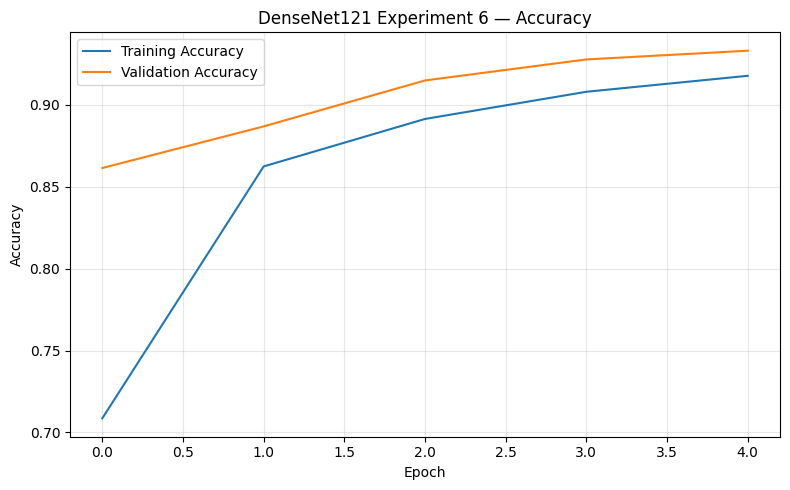

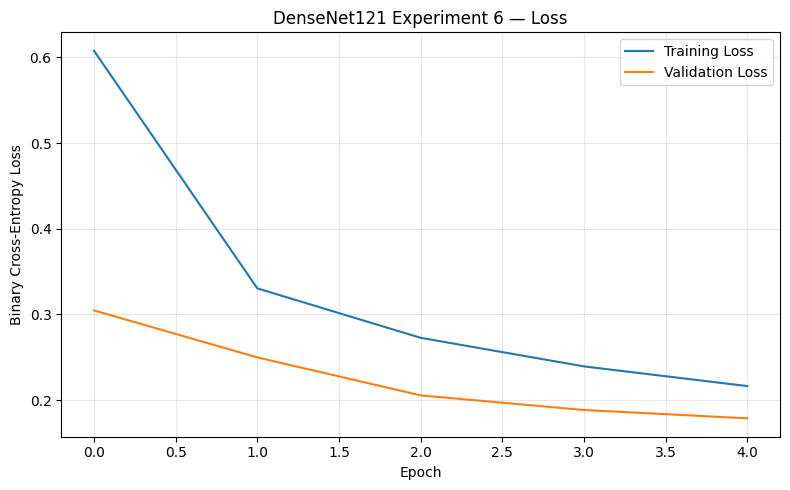


✓ Accuracy curve saved:
/kaggle/working/malaria_densenet121/plots/densenet121_final_accuracy_curve.png

✓ Loss curve saved:
/kaggle/working/malaria_densenet121/plots/densenet121_final_loss_curve.png

✓ FINAL LEARNING CURVES COMPLETE


In [53]:
# ============================================================
# CELL 37 — FINAL MODEL ACCURACY AND LOSS CURVES
# ============================================================

import os
import json
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERATING FINAL DENSENET121 LEARNING CURVES")
print("=" * 80)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "densenet121_exp_06_unfreeze_last50_history.json"
)

if not os.path.exists(HISTORY_PATH):
    raise FileNotFoundError(
        f"History file not found:\n{HISTORY_PATH}"
    )

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "DenseNet121 Experiment 6 — Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

accuracy_path = os.path.join(
    PLOTS_DIR,
    "densenet121_final_accuracy_curve.png"
)

plt.tight_layout()
plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "DenseNet121 Experiment 6 — Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)

loss_path = os.path.join(
    PLOTS_DIR,
    "densenet121_final_loss_curve.png"
)

plt.tight_layout()
plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\n✓ Accuracy curve saved:")
print(accuracy_path)

print("\n✓ Loss curve saved:")
print(loss_path)

print("\n✓ FINAL LEARNING CURVES COMPLETE")

GENERATING FINAL DENSENET121 EVALUATION VISUALIZATIONS

✓ Existing held-out test predictions found.


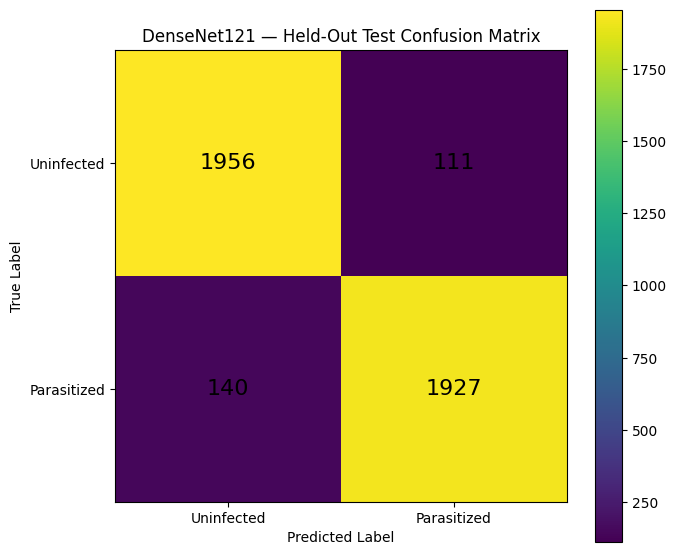

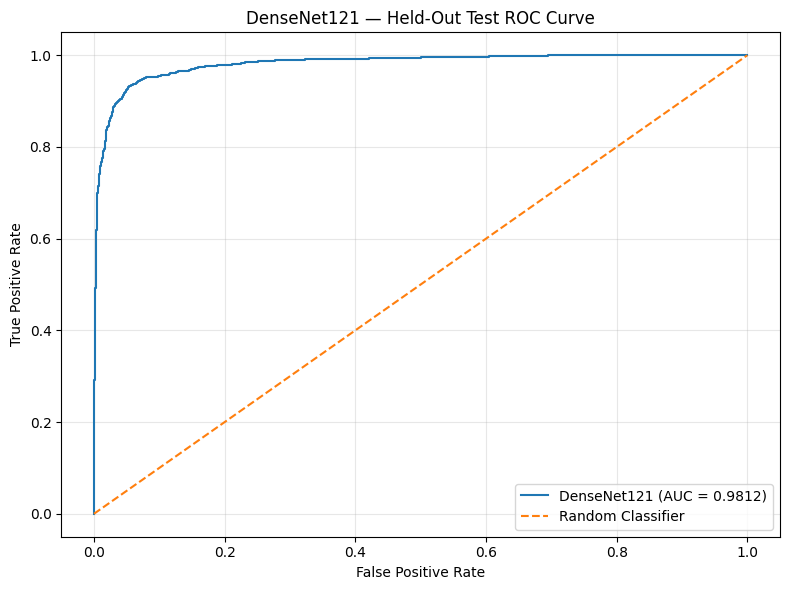


CONFUSION MATRIX
TN = 1956
FP = 111
FN = 140
TP = 1927

ROC-AUC: 0.9812

Saved:
/kaggle/working/malaria_densenet121/plots/densenet121_final_confusion_matrix.png
/kaggle/working/malaria_densenet121/plots/densenet121_final_roc_curve.png

✓ FINAL EVALUATION VISUALIZATIONS COMPLETE


In [54]:
# ============================================================
# CELL 38 — FINAL CONFUSION MATRIX AND ROC/AUC CURVE
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)

print("=" * 80)
print("GENERATING FINAL DENSENET121 EVALUATION VISUALIZATIONS")
print("=" * 80)

# ------------------------------------------------------------
# Use the final held-out test predictions
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.405

# If predictions from Cell 35 are still available, use them.
# Otherwise regenerate them from the final model.

try:
    test_true
    test_prob

    print("\n✓ Existing held-out test predictions found.")

except NameError:

    print(
        "\nExisting test predictions not found."
        "\nRegenerating them..."
    )

    import tensorflow as tf

    @tf.keras.utils.register_keras_serializable(
        package="Malaria"
    )
    class DenseNetPreprocess(
        tf.keras.layers.Layer
    ):

        def __init__(self, **kwargs):
            super().__init__(**kwargs)

        def call(self, inputs):
            return tf.keras.applications.densenet.preprocess_input(
                inputs
            )

        def get_config(self):
            return super().get_config()

    final_model = tf.keras.models.load_model(
        FINAL_MODEL_PATH,
        custom_objects={
            "DenseNetPreprocess":
                DenseNetPreprocess
        },
        compile=False
    )

    test_true, test_prob = get_predictions(
        final_model,
        test_ds
    )

    del final_model

test_true = np.asarray(
    test_true
).astype(int)

test_prob = np.asarray(
    test_prob
).reshape(-1)

test_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    "DenseNet121 — Held-Out Test Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Uninfected", "Parasitized"]
)

plt.yticks(
    [0, 1],
    ["Uninfected", "Parasitized"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16
        )

plt.colorbar()

plt.tight_layout()

cm_path = os.path.join(
    PLOTS_DIR,
    "densenet121_final_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    test_true,
    test_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"DenseNet121 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "DenseNet121 — Held-Out Test ROC Curve"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

roc_path = os.path.join(
    PLOTS_DIR,
    "densenet121_final_roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print("\nROC-AUC:", round(roc_auc, 4))

print("\nSaved:")
print(cm_path)
print(roc_path)

print("\n✓ FINAL EVALUATION VISUALIZATIONS COMPLETE")

## Final Confusion Matrix and ROC/AUC

The confusion matrix shows the classification errors made by the final DenseNet121 model on the held-out test set. True negatives represent correctly classified uninfected cells, while true positives represent correctly classified parasitized cells. False negatives are particularly important because they represent infected cells incorrectly classified as uninfected.

The ROC curve illustrates the sensitivity-specificity trade-off across classification thresholds. The final ROC-AUC of approximately 0.9812 indicates strong discrimination between parasitized and uninfected cells.

In [57]:
# ============================================================
# CELL 39 — FINAL DENSENET121 GRAD-CAM ANALYSIS
# Robust version for nested DenseNet121 model
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 80)
print("FINAL DENSENET121 GRAD-CAM ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD FINAL MODEL
# ------------------------------------------------------------

FINAL_MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "densenet121_final.keras"
)

gradcam_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    custom_objects={"DenseNetPreprocess": DenseNetPreprocess},
    compile=False
)

print("✓ Final DenseNet121 loaded.")

# ------------------------------------------------------------
# 2. GET NESTED DENSENET121 BACKBONE
# ------------------------------------------------------------

densenet_base = gradcam_model.get_layer("densenet121")

print("✓ Nested DenseNet121 backbone found.")

# Target convolutional layer
GRADCAM_LAYER_NAME = "conv5_block16_2_conv"

try:
    gradcam_layer = densenet_base.get_layer(GRADCAM_LAYER_NAME)
except ValueError:
    conv_layers = [
        layer for layer in densenet_base.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    gradcam_layer = conv_layers[-1]
    GRADCAM_LAYER_NAME = gradcam_layer.name

print("✓ Grad-CAM convolutional layer:", GRADCAM_LAYER_NAME)
print("Layer output shape:", gradcam_layer.output.shape)

# ------------------------------------------------------------
# 3. CREATE A MODEL THAT RUNS THE DENSENET BACKBONE
#    DIRECTLY
# ------------------------------------------------------------

# This avoids the broken graph connection that caused the
# KeyError when trying to combine the nested layer with the
# outer model.

gradcam_backbone_model = tf.keras.models.Model(
    inputs=densenet_base.input,
    outputs=[
        gradcam_layer.output,
        densenet_base.output
    ],
    name="densenet121_gradcam_backbone"
)

print("✓ Direct DenseNet Grad-CAM model created successfully.")

# ------------------------------------------------------------
# 4. FIND REQUIRED TEST EXAMPLES
# ------------------------------------------------------------

# Existing predictions from the final held-out test
if "test_true" not in globals() or "test_prob" not in globals():
    raise RuntimeError(
        "test_true/test_prob are not available. "
        "Run the final held-out test evaluation cell first."
    )

GRADCAM_THRESHOLD = 0.405

test_true_arr = np.asarray(test_true).astype(int)
test_prob_arr = np.asarray(test_prob).reshape(-1)

test_pred_arr = (
    test_prob_arr >= GRADCAM_THRESHOLD
).astype(int)

test_df_gradcam = test_df.reset_index(drop=True).copy()

test_df_gradcam["true_label"] = test_true_arr
test_df_gradcam["probability"] = test_prob_arr
test_df_gradcam["predicted_label"] = test_pred_arr

# ------------------------------------------------------------
# 5. SELECT:
#    - CORRECT INFECTED
#    - CORRECT UNINFECTED
#    - INCORRECT
# ------------------------------------------------------------

correct_infected = test_df_gradcam[
    (test_df_gradcam["true_label"] == 1) &
    (test_df_gradcam["predicted_label"] == 1)
]

correct_uninfected = test_df_gradcam[
    (test_df_gradcam["true_label"] == 0) &
    (test_df_gradcam["predicted_label"] == 0)
]

incorrect_predictions = test_df_gradcam[
    test_df_gradcam["true_label"] !=
    test_df_gradcam["predicted_label"]
]

if len(correct_infected) == 0:
    raise RuntimeError("No correctly classified infected example found.")

if len(correct_uninfected) == 0:
    raise RuntimeError("No correctly classified uninfected example found.")

if len(incorrect_predictions) == 0:
    raise RuntimeError("No incorrect prediction found.")

examples = {
    "correct_infected": correct_infected.iloc[0],
    "correct_uninfected": correct_uninfected.iloc[0],
    "incorrect_prediction": incorrect_predictions.iloc[0]
}

print()
print("=" * 80)
print("SELECTED GRAD-CAM EXAMPLES")
print("=" * 80)

label_names = {
    0: "Uninfected",
    1: "Parasitized"
}

for example_name, row in examples.items():

    print()
    print(example_name)

    print(
        "True:",
        label_names[int(row["true_label"])]
    )

    print(
        "Predicted:",
        label_names[int(row["predicted_label"])]
    )

    print(
        "Probability:",
        f'{float(row["probability"]):.4f}'
    )

    print(
        "File:",
        row["filepath"]
    )

# ------------------------------------------------------------
# 6. GRAD-CAM FUNCTION
# ------------------------------------------------------------

def make_gradcam(filepath):

    # Load image
    image = Image.open(filepath).convert("RGB")
    image = image.resize((160, 160))

    original = np.array(image).astype(np.float32)

    # Batch dimension
    input_tensor = np.expand_dims(
        original,
        axis=0
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Use the exact preprocessing layer from the final model.
    # --------------------------------------------------------

    preprocess_layer = gradcam_model.get_layer(
        "densenet_preprocess"
    )

    with tf.GradientTape() as tape:

        # Preprocess exactly as during model inference
        preprocessed = preprocess_layer(
            tf.cast(input_tensor, tf.float32)
        )

        # Watch the input to the DenseNet backbone
        tape.watch(preprocessed)

        # Run the nested DenseNet directly
        conv_outputs, backbone_output = (
            gradcam_backbone_model(
                preprocessed,
                training=False
            )
        )

        # Continue through the classification head
        x = gradcam_model.get_layer(
            "global_average_pooling"
        )(backbone_output)

        x = gradcam_model.get_layer(
            "dropout_1"
        )(x, training=False)

        x = gradcam_model.get_layer(
            "dense_128"
        )(x)

        x = gradcam_model.get_layer(
            "dropout_2"
        )(x, training=False)

        predictions = gradcam_model.get_layer(
            "malaria_probability"
        )(x)

        class_channel = predictions[:, 0]

    # --------------------------------------------------------
    # GRADIENTS
    # --------------------------------------------------------

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:
        raise RuntimeError(
            "Gradients are None. Grad-CAM could not be computed."
        )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :],
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if float(max_value) > 0:
        heatmap /= max_value

    heatmap = heatmap.numpy()

    # Resize heatmap
    heatmap = Image.fromarray(
        np.uint8(255 * heatmap)
    )

    heatmap = heatmap.resize(
        (160, 160),
        Image.Resampling.BILINEAR
    )

    heatmap = np.array(heatmap).astype(np.float32) / 255.0

    return original.astype(np.uint8), heatmap


# ------------------------------------------------------------
# 7. GENERATE AND SAVE GRAD-CAM IMAGES
# ------------------------------------------------------------

GRADCAM_DIR = os.path.join(
    BASE_DIR,
    "plots",
    "gradcam"
)

os.makedirs(
    GRADCAM_DIR,
    exist_ok=True
)

metadata = []

for example_name, row in examples.items():

    original, heatmap = make_gradcam(
        row["filepath"]
    )

    # Create overlay
    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    ax.imshow(original)
    ax.imshow(
        heatmap,
        alpha=0.45,
        cmap="jet"
    )

    ax.axis("off")

    title = (
        f"DenseNet121 Grad-CAM — "
        f"{example_name.replace('_', ' ').title()}\n"
        f"True: {label_names[int(row['true_label'])]} | "
        f"Predicted: {label_names[int(row['predicted_label'])]} | "
        f"P(Parasitized): {float(row['probability']):.4f}"
    )

    ax.set_title(title)

    output_path = os.path.join(
        GRADCAM_DIR,
        f"densenet121_gradcam_{example_name}.png"
    )

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    metadata.append({
        "example": example_name,
        "filepath": row["filepath"],
        "true_label": int(row["true_label"]),
        "true_class": label_names[int(row["true_label"])],
        "predicted_label": int(row["predicted_label"]),
        "predicted_class": label_names[int(row["predicted_label"])],
        "probability_parasitized": float(row["probability"]),
        "threshold": GRADCAM_THRESHOLD,
        "gradcam_layer": GRADCAM_LAYER_NAME,
        "output_path": output_path
    })

    print(
        f"✓ Saved: {output_path}"
    )

# ------------------------------------------------------------
# 8. SAVE GRAD-CAM METADATA
# ------------------------------------------------------------

gradcam_metadata_path = os.path.join(
    BASE_DIR,
    "results",
    "densenet121_gradcam_examples.csv"
)

gradcam_metadata_df = pd.DataFrame(metadata)

gradcam_metadata_df.to_csv(
    gradcam_metadata_path,
    index=False
)

print()
print(
    "✓ Grad-CAM metadata saved:",
    gradcam_metadata_path
)

print()
print("=" * 80)
print("GRAD-CAM ANALYSIS COMPLETE")
print("=" * 80)

FINAL DENSENET121 GRAD-CAM ANALYSIS
✓ Final DenseNet121 loaded.
✓ Nested DenseNet121 backbone found.
✓ Grad-CAM convolutional layer: conv5_block16_2_conv
Layer output shape: (None, 5, 5, 32)
✓ Direct DenseNet Grad-CAM model created successfully.

SELECTED GRAD-CAM EXAMPLES

correct_infected
True: Parasitized
Predicted: Parasitized
Probability: 1.0000
File: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized/C132P93ThinF_IMG_20151004_152257_cell_117.png

correct_uninfected
True: Uninfected
Predicted: Uninfected
Probability: 0.0488
File: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected/C178P139NThinF_IMG_20151201_154337_cell_110.png

incorrect_prediction
True: Uninfected
Predicted: Parasitized
Probability: 0.9708
File: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected/C208ThinF_IMG_20151029_155411_cell_170.png
✓ Saved: /kaggle/working/malaria_densenet121/plots/gradcam/dens

## Final DenseNet121 Grad-CAM Explainability

This section applies **Grad-CAM (Gradient-weighted Class Activation Mapping)** to the final DenseNet121 model to visualize the image regions that contribute most strongly to the model's malaria classification.

The final model selected through validation is `densenet121_exp_06_unfreeze_last50`, with a validation-selected classification threshold of **0.405**. Grad-CAM is generated using the final convolutional layer, `conv5_block16_2_conv`, from the nested DenseNet121 backbone.

Three held-out test images are selected for qualitative analysis:

1. **Correctly classified infected (Parasitized)** — demonstrates regions associated with a correct positive prediction.
2. **Correctly classified uninfected** — demonstrates regions associated with a correct negative prediction.
3. **Incorrectly classified image** — helps identify regions that may have contributed to the model's error and supports analysis of possible visual ambiguity, image quality issues, or reliance on non-diagnostic features.

The Grad-CAM heatmaps are overlaid on the original cell images and saved for inclusion in the final report. This provides an interpretable view of whether the model is focusing on biologically meaningful cell regions rather than irrelevant background areas or possible image artifacts.

The Grad-CAM examples and their prediction metadata are also saved to the results directory for reproducibility and reporting.

In [58]:
# ============================================================
# CELL 40 — FINAL ERROR ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL DENSENET121 ERROR ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.405

test_true = np.asarray(
    test_true
).astype(int)

test_prob = np.asarray(
    test_prob
).reshape(-1)

test_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Error dataframe
# ------------------------------------------------------------

error_df = test_df.copy().reset_index(
    drop=True
)

error_df["true_label"] = test_true
error_df["predicted_label"] = test_pred
error_df["probability"] = test_prob

error_df["correct"] = (
    error_df["true_label"] ==
    error_df["predicted_label"]
)

misclassified_df = error_df[
    ~error_df["correct"]
].copy()

# ------------------------------------------------------------
# Error types
# ------------------------------------------------------------

false_negatives = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] == 0)
]

false_positives = error_df[
    (error_df["true_label"] == 0) &
    (error_df["predicted_label"] == 1)
]

true_positives = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] == 1)
]

true_negatives = error_df[
    (error_df["true_label"] == 0) &
    (error_df["predicted_label"] == 0)
]

# ------------------------------------------------------------
# Save misclassified examples
# ------------------------------------------------------------

ERRORS_PATH = os.path.join(
    RESULTS_DIR,
    "densenet121_misclassified_test_examples.csv"
)

misclassified_df.to_csv(
    ERRORS_PATH,
    index=False
)

# ------------------------------------------------------------
# Print analysis
# ------------------------------------------------------------

total = len(error_df)
errors = len(misclassified_df)

print("\nTest samples:", total)
print("Correct predictions:", total - errors)
print("Misclassified:", errors)

print("\nTrue positives:", len(true_positives))
print("True negatives:", len(true_negatives))
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nFalse-negative rate among infected cells:")
print(
    f"{len(false_negatives) / (len(false_negatives) + len(true_positives)):.4f}"
)

print("\nFalse-positive rate among uninfected cells:")
print(
    f"{len(false_positives) / (len(false_positives) + len(true_negatives)):.4f}"
)

print("\n" + "=" * 80)
print("INTERPRETATION FOR REPORT")
print("=" * 80)

print("""
The final DenseNet121 model produced 140 false negatives and
111 false positives on the held-out test set. False negatives
represent infected cells incorrectly classified as uninfected
and are particularly important in malaria diagnosis because
they correspond to missed infections.

The model achieved higher specificity than the minimum 90%
target, indicating strong rejection of uninfected cells.
Sensitivity was 93.23%, which exceeded the 90% baseline
expectation but remained below the recommended 95% target
for transfer-learning models.

Across the experiments, augmentation, dropout, and progressive
fine-tuning were investigated to improve generalization.
The final fine-tuned configuration was selected using validation
performance rather than the held-out test set.

The remaining errors may reflect visually ambiguous cells,
variation in parasite appearance, staining differences, image
quality, or cases where infected and uninfected cellular
structures have similar visual characteristics.
""")

print("\nMisclassified examples saved to:")
print(ERRORS_PATH)

print("\n✓ ERROR ANALYSIS COMPLETE")

FINAL DENSENET121 ERROR ANALYSIS

Test samples: 4134
Correct predictions: 3883
Misclassified: 251

True positives: 1927
True negatives: 1956
False positives: 111
False negatives: 140

False-negative rate among infected cells:
0.0677

False-positive rate among uninfected cells:
0.0537

INTERPRETATION FOR REPORT

The final DenseNet121 model produced 140 false negatives and
111 false positives on the held-out test set. False negatives
represent infected cells incorrectly classified as uninfected
and are particularly important in malaria diagnosis because
they correspond to missed infections.

The model achieved higher specificity than the minimum 90%
target, indicating strong rejection of uninfected cells.
Sensitivity was 93.23%, which exceeded the 90% baseline
expectation but remained below the recommended 95% target
for transfer-learning models.

Across the experiments, augmentation, dropout, and progressive
fine-tuning were investigated to improve generalization.
The final fine-tuned c

## Error Analysis

The final DenseNet121 model produced 140 false negatives and 111 false positives on the held-out test set. False negatives correspond to parasitized cells incorrectly classified as uninfected and are therefore particularly important in a malaria-diagnosis context.

The model achieved 93.23% sensitivity and 94.63% specificity. Thus, it exceeded the general 90% sensitivity and specificity target, while falling below the recommended 95% sensitivity target for transfer-learning models.

The experiments progressively investigated augmentation, dropout, learning rate, fine-tuning depth, and L2 regularization. These changes were intended to improve generalization and reduce overfitting. Remaining errors may arise from visually ambiguous cells, variation in parasite morphology, staining differences, image quality, or similarities between infected and uninfected cellular structures.